<span style="color: #177cff ; font-size: 40px;">Question 1: Hypergeometric and Binomial Distributions</span>

<span style="color: gold; font-size: 30px;">Part 1: Hypergeometric Distribution</span>

We simulate the distribution by doing the experiment 150 times.
First I implement this distribution manually using for loop.

In [ ]:
set.seed(467)

n <- 150
N <- 100
num_of_cheaters = 20
num_of_selections = 40
results <- c()

for(i in 1:n){
    districts <- 1:N
    cheater_districts <- sample(districts, num_of_cheaters)
    sampled_districts <- sample(districts, num_of_selections)
    num_of_cheater_samples <- sum(sampled_districts %in% cheater_districts)
    results <- c(results, num_of_cheater_samples)
}



Or we can use the predefined function instead. 
There is the rhyper() function in r which does exactly the same.

In [2]:
results_v2 <- rhyper(n, num_of_cheaters, N - num_of_cheaters, num_of_selections)

Now I plot both the results using a histogram.

They are exactly the same, but generated with two different methods. Because the distributions are random in essence they are probabely distributed differently.

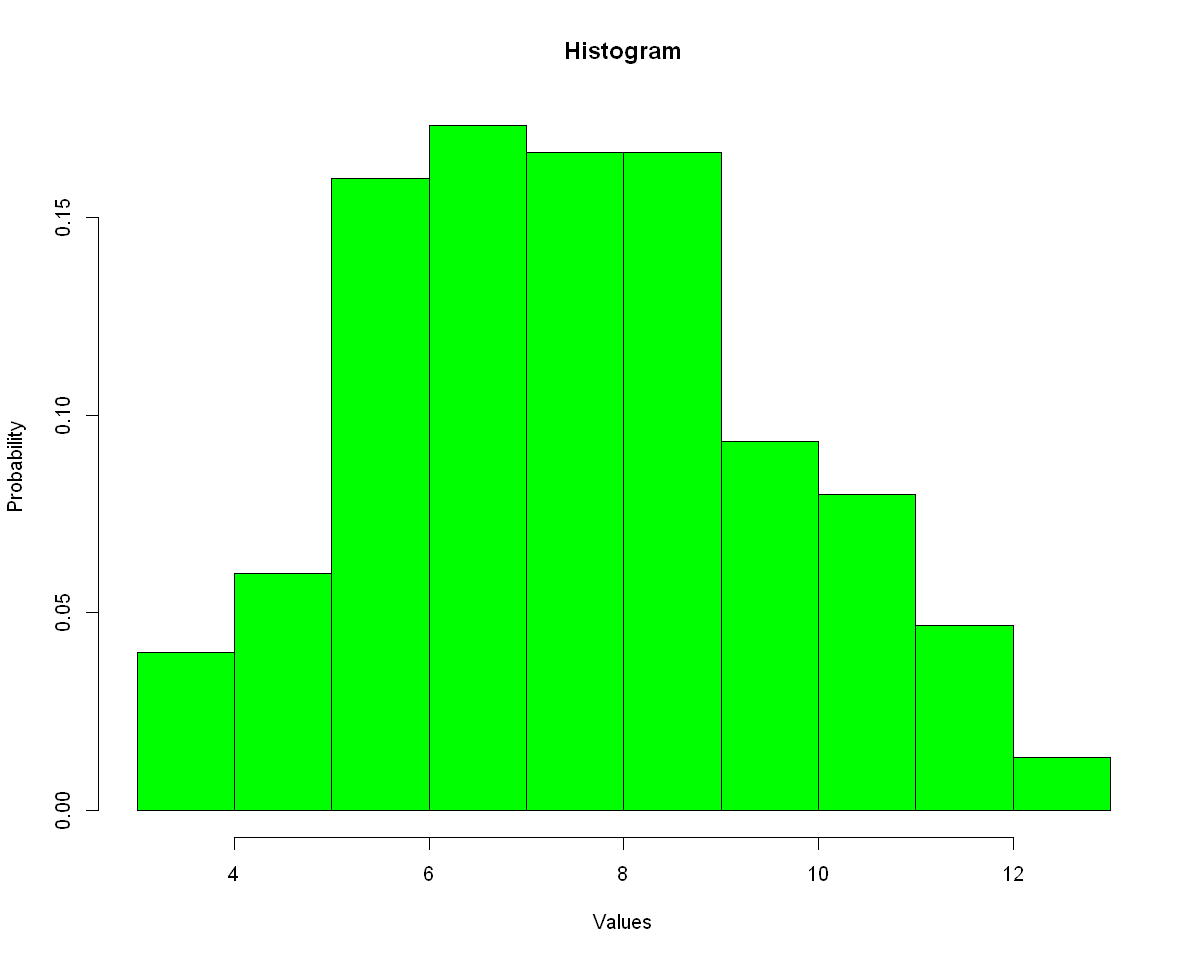

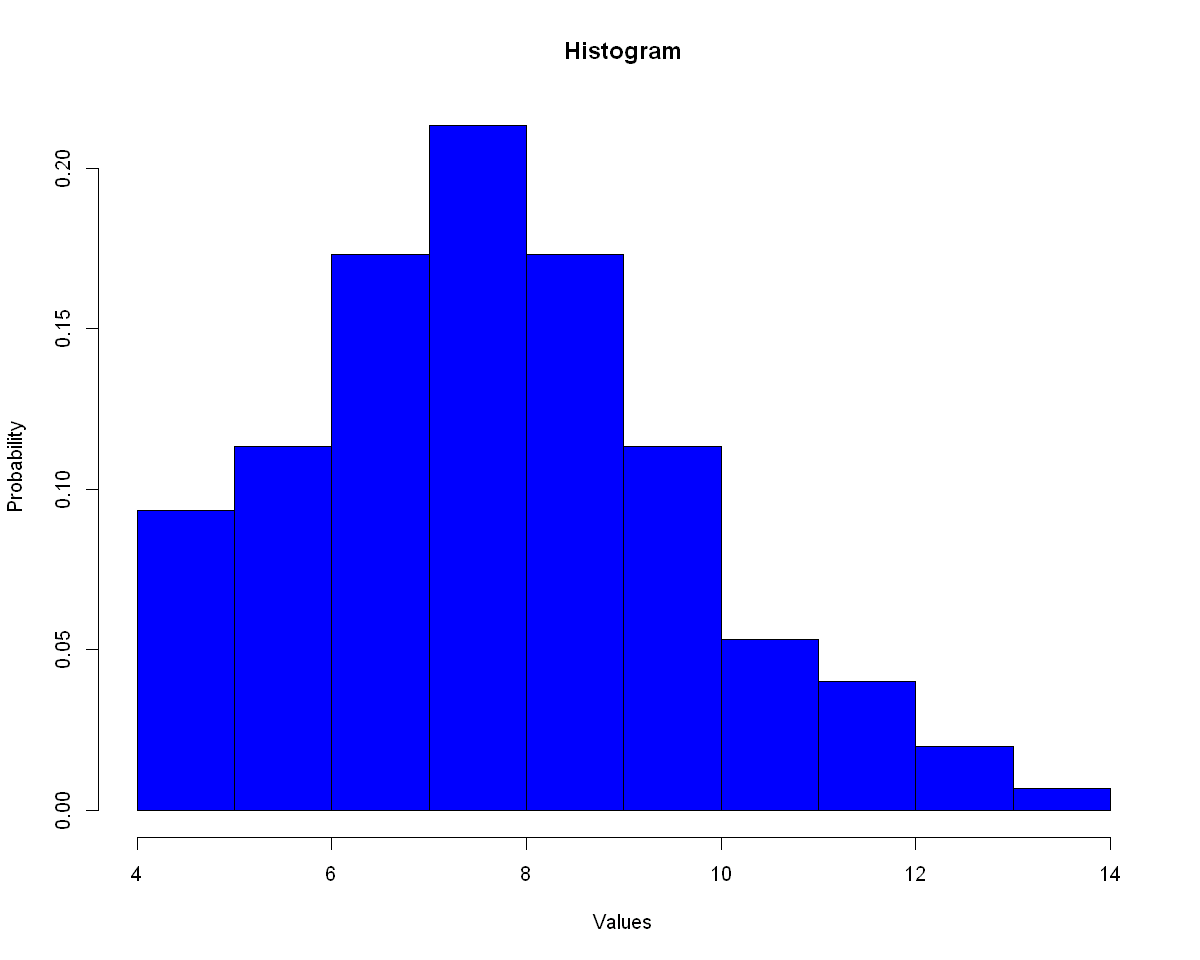

In [3]:
options(repr.plot.width = 10, repr.plot.height = 8) #Just to make the histograms more well-sized.

hist(results, col = "green", main = "Histogram", xlab = "Values", ylab = "Probability", prob = TRUE)
hist(results_v2, col = "blue", main = "Histogram", xlab = "Values", ylab = "Probability", prob = TRUE)

<span style="color: gold; font-size: 30px;">Part 2: Theoretical and Simulated Variances and Expectations</span>

This function returns a R data frame which has both theoretical and simulated values for variances and expectations.


In [4]:
calculate_vars_expectations <- function(n_min, n_max, N, num_of_cheaters, step, num_of_selections){
    num_of_simulations <- (n_max - n_min) / step + 1
    n_values <- seq(n_min, n_max, by = step)

    results <- data.frame(n = n_values, 
                          theoretical_expectation = numeric(num_of_simulations), 
                          theoretical_variance = numeric(num_of_simulations),
                          simulated_expectation = numeric(num_of_simulations), 
                          simulated_variance = numeric(num_of_simulations))

    for(i in 1:num_of_simulations){
        n = n_values[i]
        p <- num_of_cheaters / N
        theoretical_expectation <- num_of_selections * p
        theoretical_variance <- num_of_selections * p * (1 - num_of_cheaters / N) * ((N - num_of_selections) / (N - 1))
        
        simulated_samples <- rhyper(n, num_of_cheaters, N - num_of_cheaters, num_of_selections)
        simulated_expectation <- mean(simulated_samples)
        simulated_variance <- var(simulated_samples)
        
        results$theoretical_expectation[i] <- theoretical_expectation
        results$theoretical_variance[i] <- theoretical_variance
        results$simulated_expectation[i] <- simulated_expectation
        results$simulated_variance[i] <- simulated_variance
    }

    return(results) 
}

n_max <- 10000
n_min <- 100
step <- 50
results <- calculate_vars_expectations(n_min, n_max, N, num_of_cheaters, step, num_of_selections)



<span style="color: gold; font-size: 30px;">Part 3: Plotting Part 2</span>

In this part I'm gonna plot the simulated and theoretical values to convert them. 

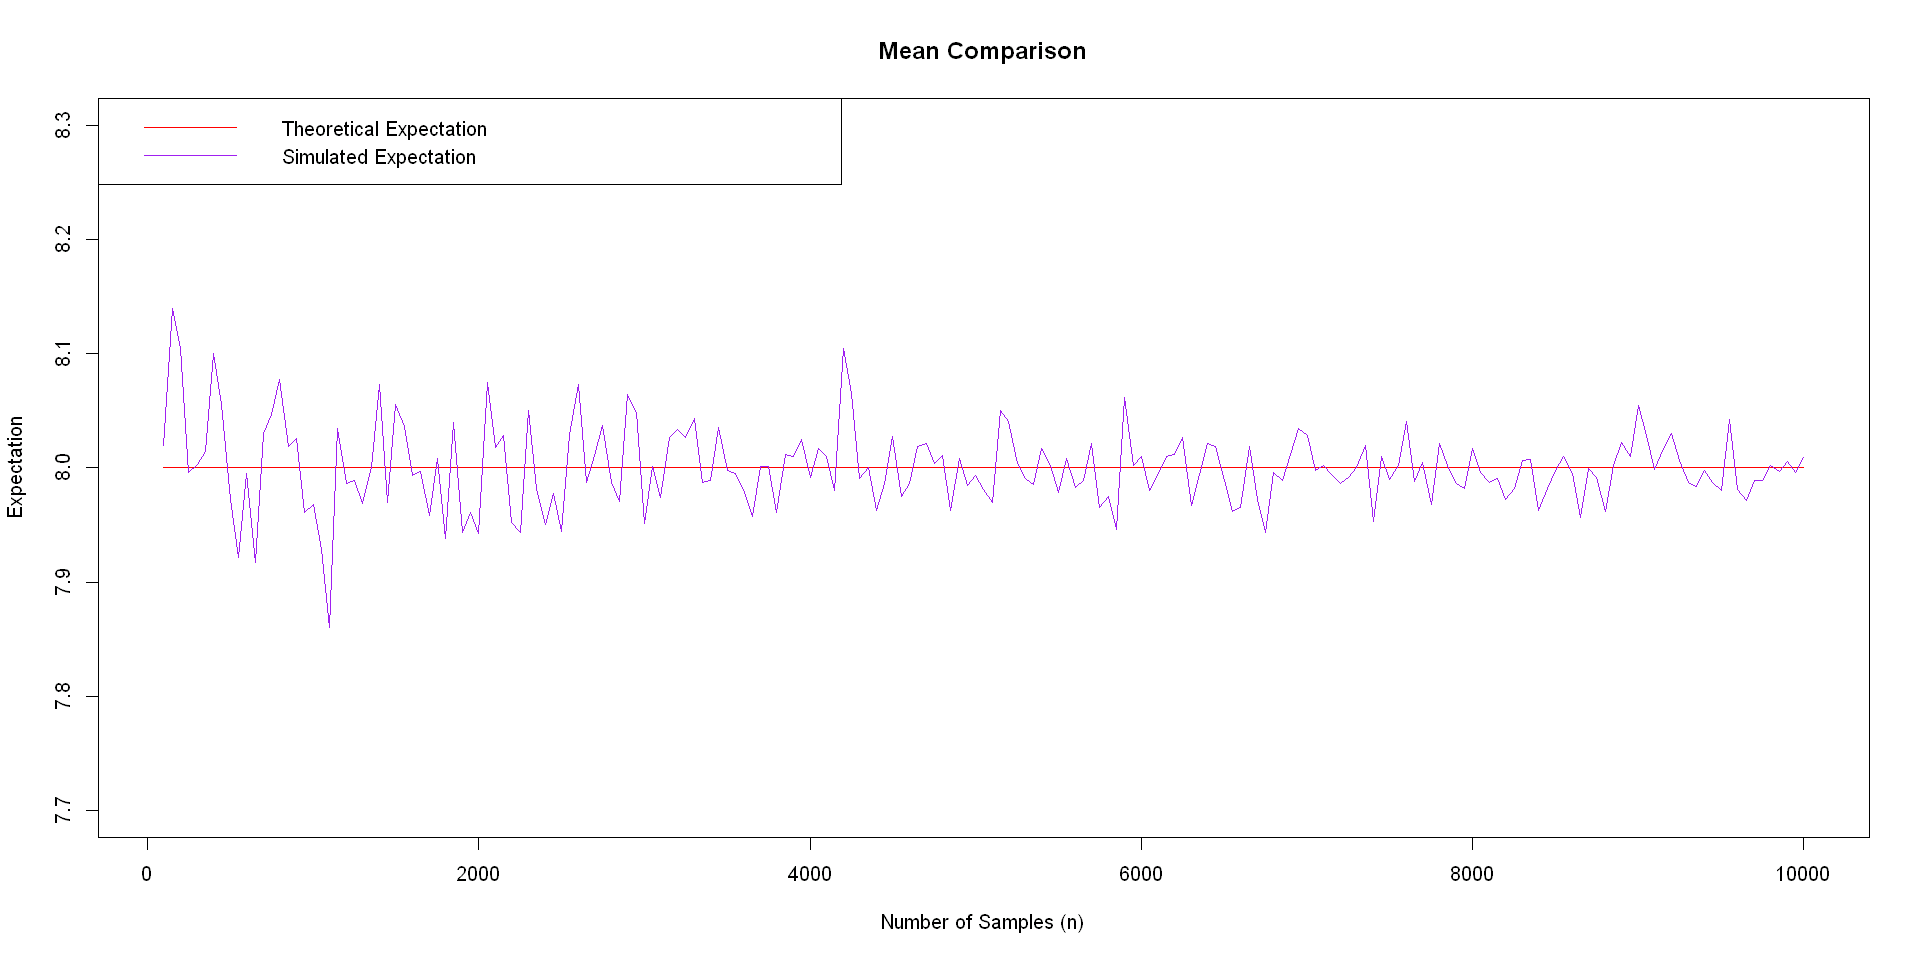

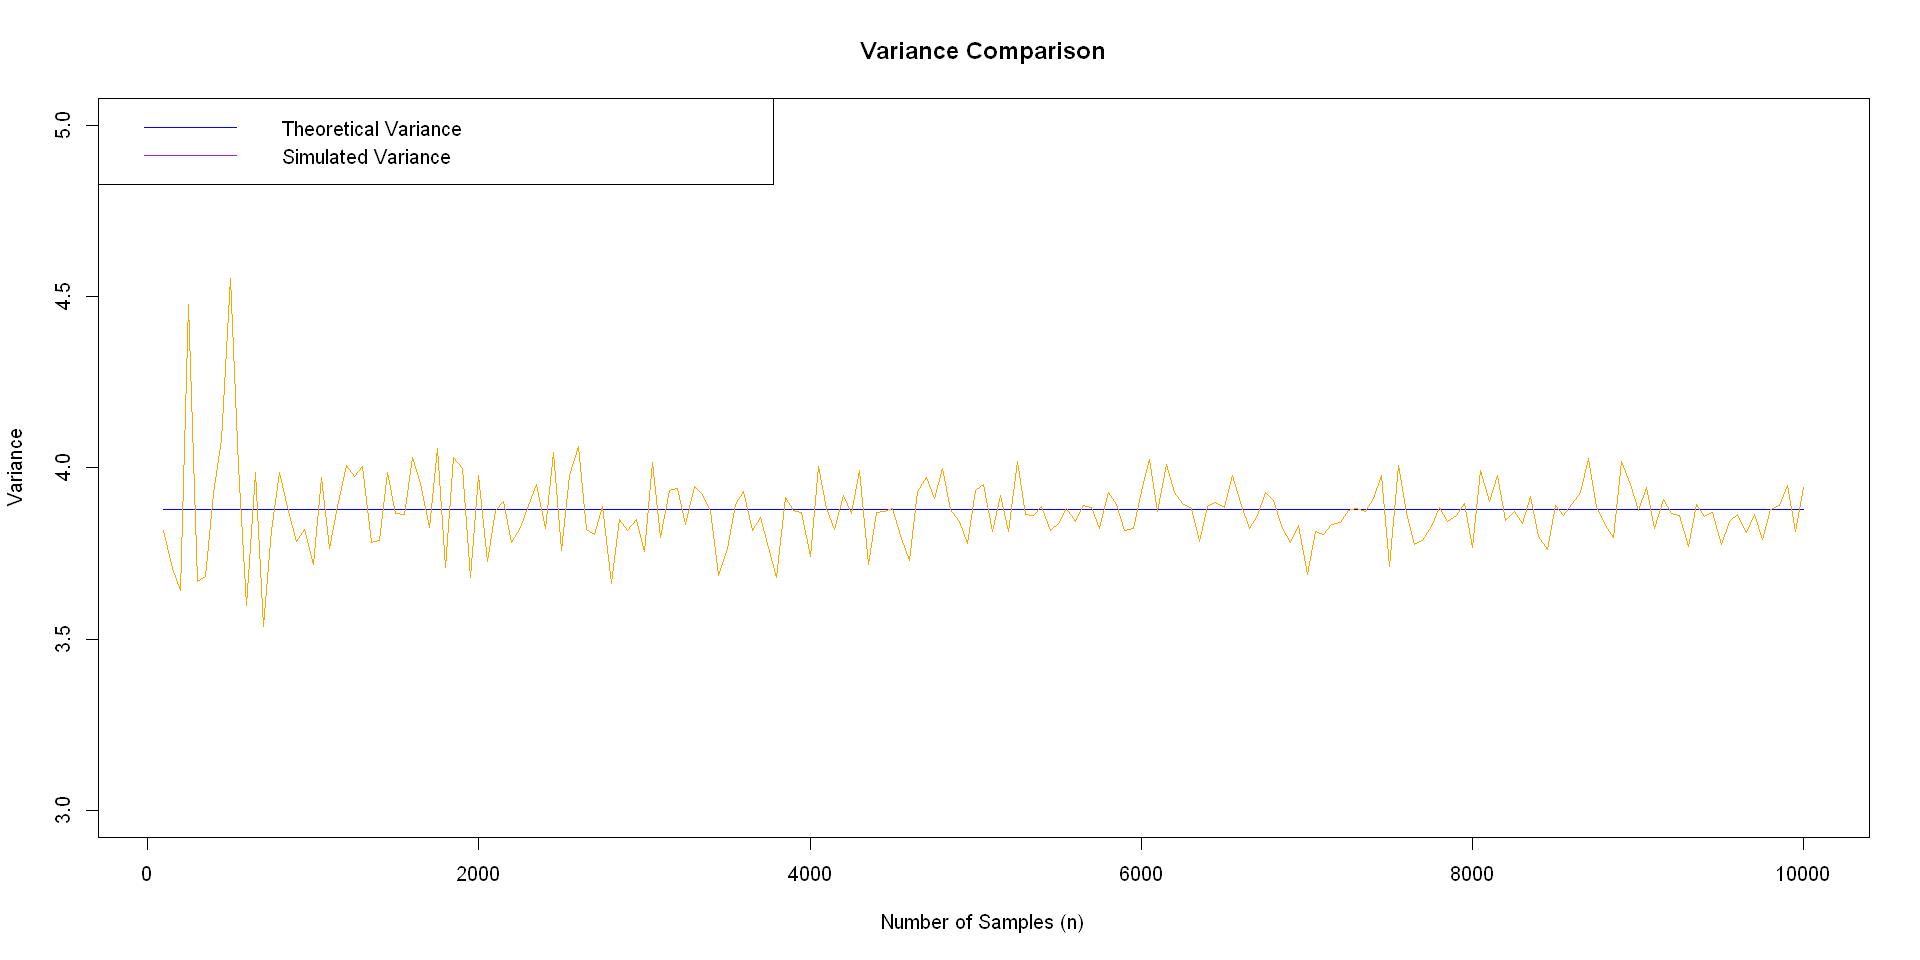

In [5]:
options(repr.plot.width = 16, repr.plot.height = 8) #Just to adjust the size of plots and make them bigger.

n_values <- seq(n_min, n_max, by = step)

plot(n_values, results$theoretical_expectation, type = "l", col = "red", 
     xlab = "Number of Samples (n)", ylab = "Expectation", 
     main = "Mean Comparison", ylim = c(7.7, 8.3))
lines(n_values, results$simulated_expectation, col = "purple")
legend("topleft", legend = c("Theoretical Expectation", "Simulated Expectation"), col = c("red", "purple"), lty = 1)

plot(n_values, results$theoretical_variance, type = "l", col = "blue", 
     xlab = "Number of Samples (n)", ylab = "Variance", 
     main = "Variance Comparison", ylim = c(3, 5))
lines(n_values, results$simulated_variance, col = "orange")
legend("topleft", legend = c("Theoretical Variance", "Simulated Variance"), col = c("blue", "purple"), lty = 1)

To conclude we can say that if we increase the n(make it close enough to infinity), then the values for mean and variance aquired by simulations are going to be converge to their theoretical values. 

<span style="color: gold; font-size: 30px;">Part 4: Keeping n Constant and Changing m</span>

I'll keep the variable n equal to 1000 and change the variable num_of_selections over [40, 60, 80, 100]. 

Warning message in hist.default(temp_distribution, breaks = seq(0, N + 1, by = 1), :
"argument 'probability' is not made use of"
Warning message in hist.default(temp_distribution, breaks = seq(0, N + 1, by = 1), :
"argument 'probability' is not made use of"
Warning message in hist.default(temp_distribution, breaks = seq(0, N + 1, by = 1), :
"argument 'probability' is not made use of"
Warning message in hist.default(temp_distribution, breaks = seq(0, N + 1, by = 1), :
"argument 'probability' is not made use of"


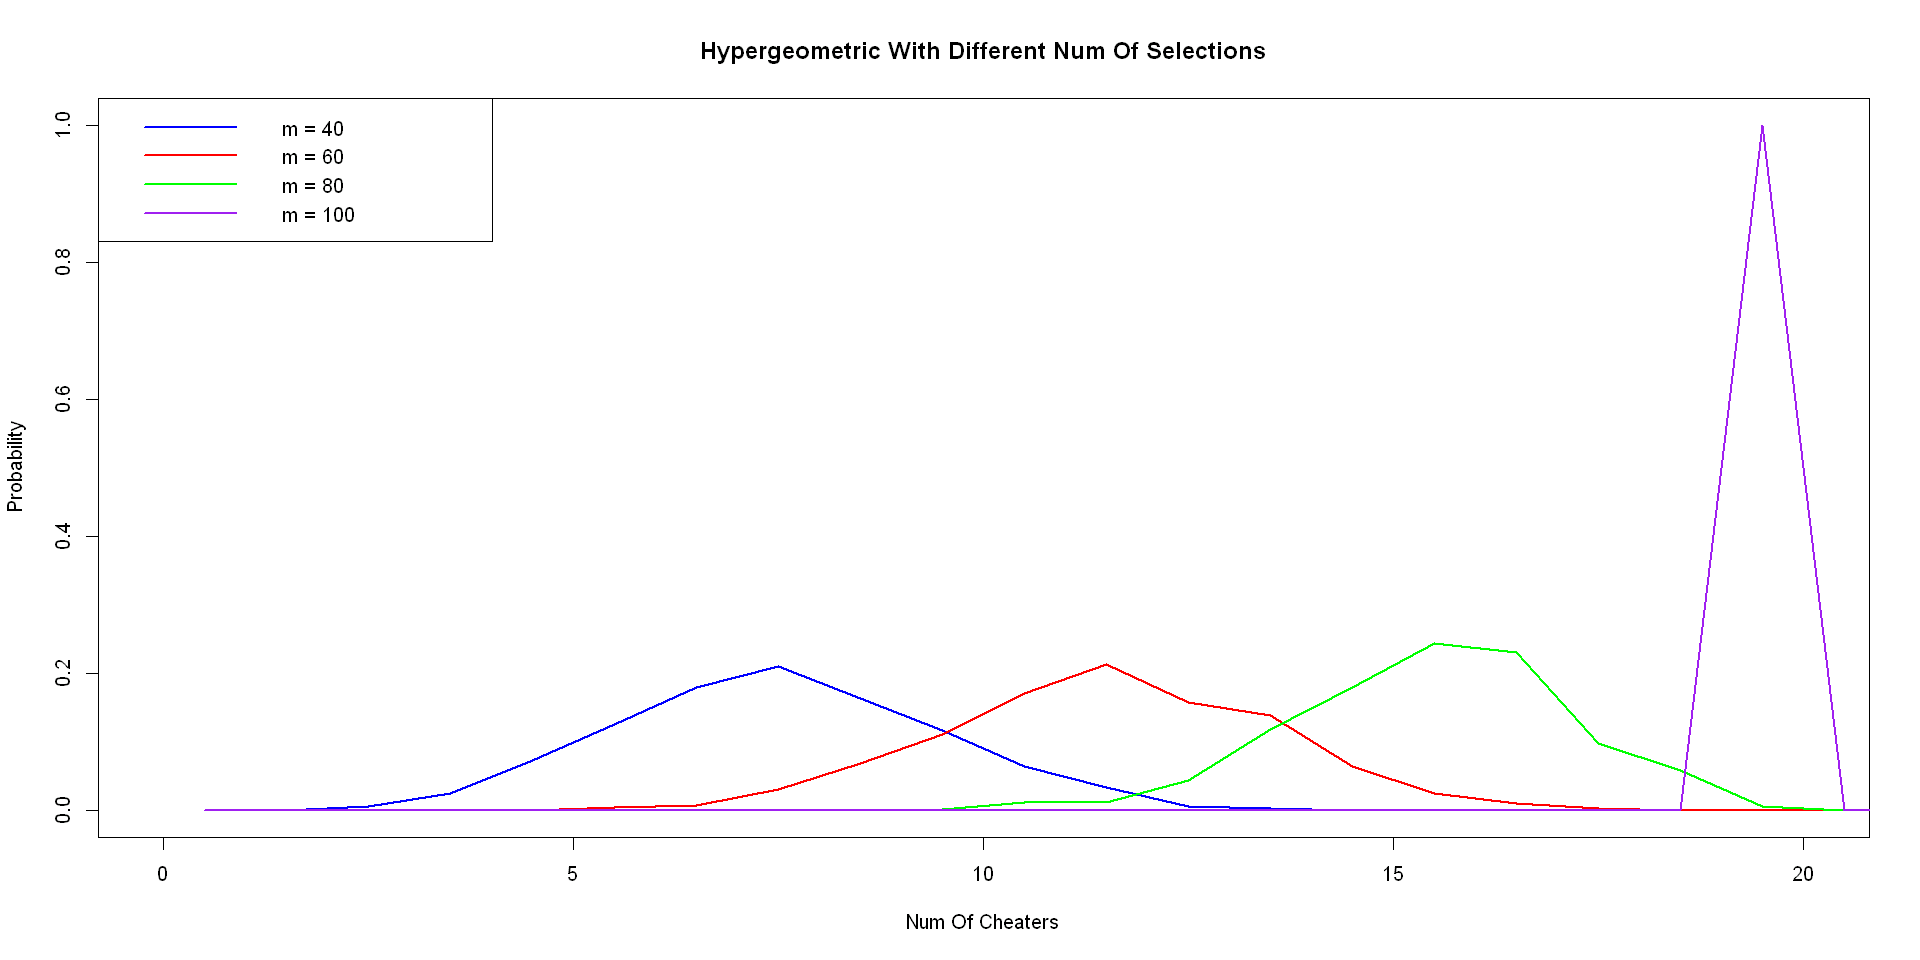

In [6]:
n <- 1000
num_of_selections_values <- c(40, 60, 80, 100)
num_of_vals = length(num_of_selections_values)

colors <- c("blue", "red", "green", "purple")

plot(NULL, xlim = c(0, num_of_cheaters), ylim = c(0, 1), 
     xlab = "Num Of Cheaters", 
     ylab = "Probability", 
     main = "Hypergeometric With Different Num Of Selections")

for (i in 1:num_of_vals) {
  m <- num_of_selections_values[i]
  
  temp_distribution <- rhyper(n, num_of_cheaters, N - num_of_cheaters, m)
  hist_data <- hist(temp_distribution, breaks = seq(0, N + 1, by = 1), plot = FALSE, prob = TRUE)
  
  lines(hist_data$mids, hist_data$density, type = "l", col = colors[i], lwd = 2)
}

legend("topleft", legend = paste("m =", num_of_selections_values), col = colors, lty = 1, lwd = 2)


As we can see, when m equals 100 because we have selected all of the districts the number of cheaters we have encountered is equal to 20 which is equal to the whole number of cheaters; becuase we have checked all of the districts. 

For each of other values for m there is a peak approximately on m * N/K which is the expectation of distribution. 

<span style="color: gold; font-size: 30px;">Part 5: Functions For Calculating PMF For Hypergeometric and Binomial Distributions</span>


In [7]:
calculate_hypergeometric_pmf <- function(N, K, n, x_values) {
    #   pmf_values <- dhyper(x_values, K, N - K, n)
    num_of_xs <- length(x_values)
    pmf_values <- numeric(num_of_xs)

    for(i in 1:num_of_xs){
        x <- x_values[i]
        pmf_values[i] <- (choose(K, x) * choose(N - K, n - x)) / choose(N, n)
    }

    return(pmf_values)
}

calculate_binomial_pmf <- function(n, p, x_values) {
    # pmf_values <- dbinom(x_values, n, p)
    num_of_xs <- length(x_values)
    pmf_values <- numeric(num_of_xs)

    for(i in 1:num_of_xs){
        x <- x_values[i]
        pmf_values[i] <- choose(n, x) * p^x * (1 - p)^(n - x) 
    }

    return(pmf_values)
}

<span style="color: gold; font-size: 30px;">Part 6: Hypergeometric and Binomial PMFs</span>

In this part I'll plot the shape of pmf function for both of the distributions for different Ns. 

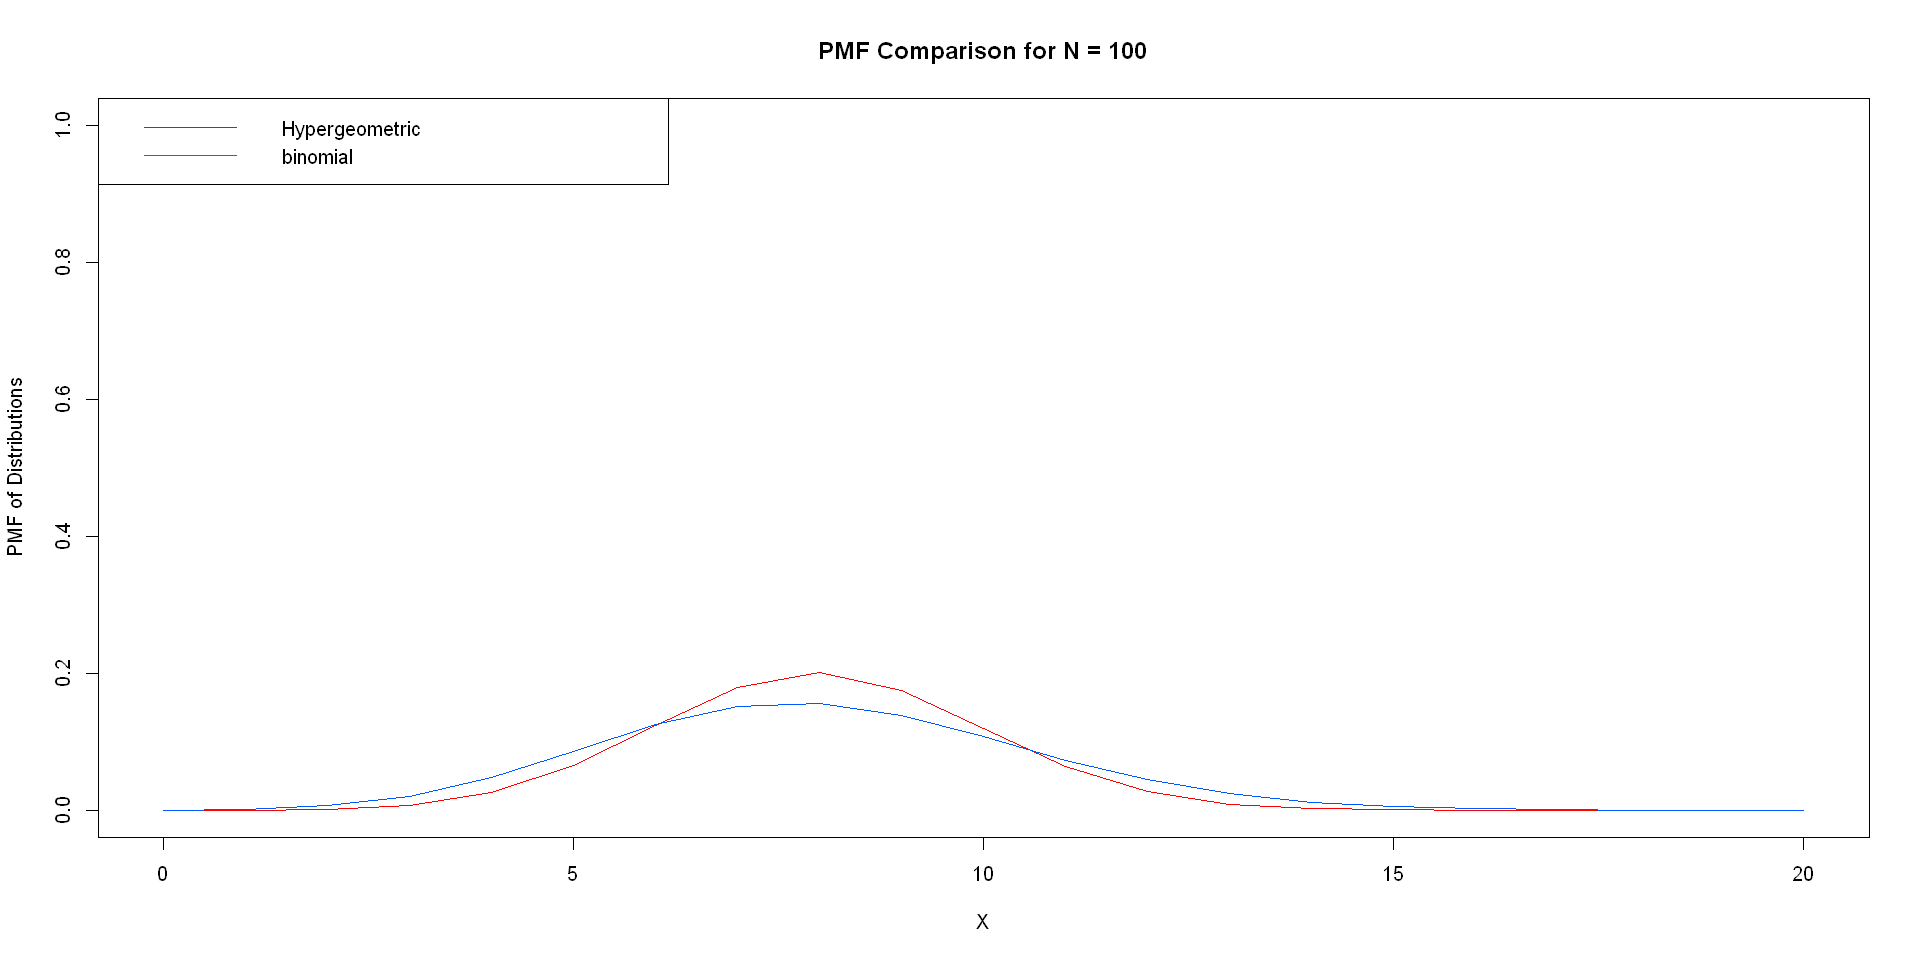

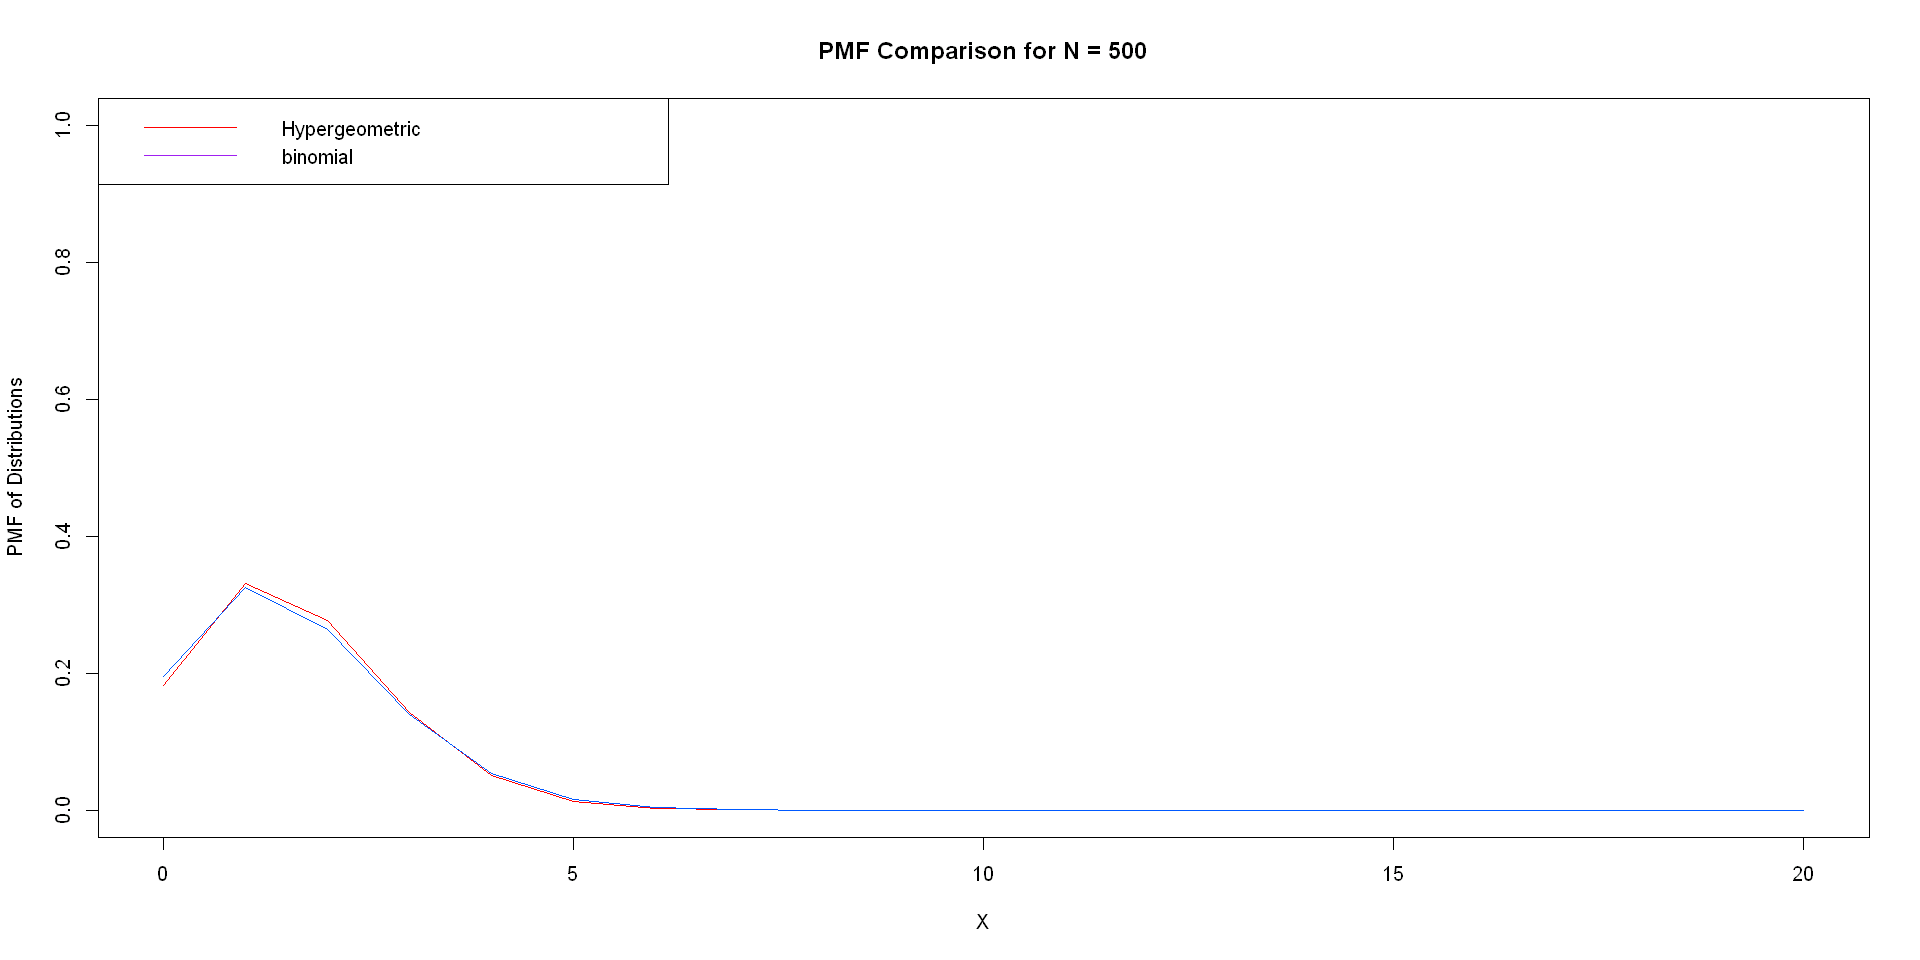

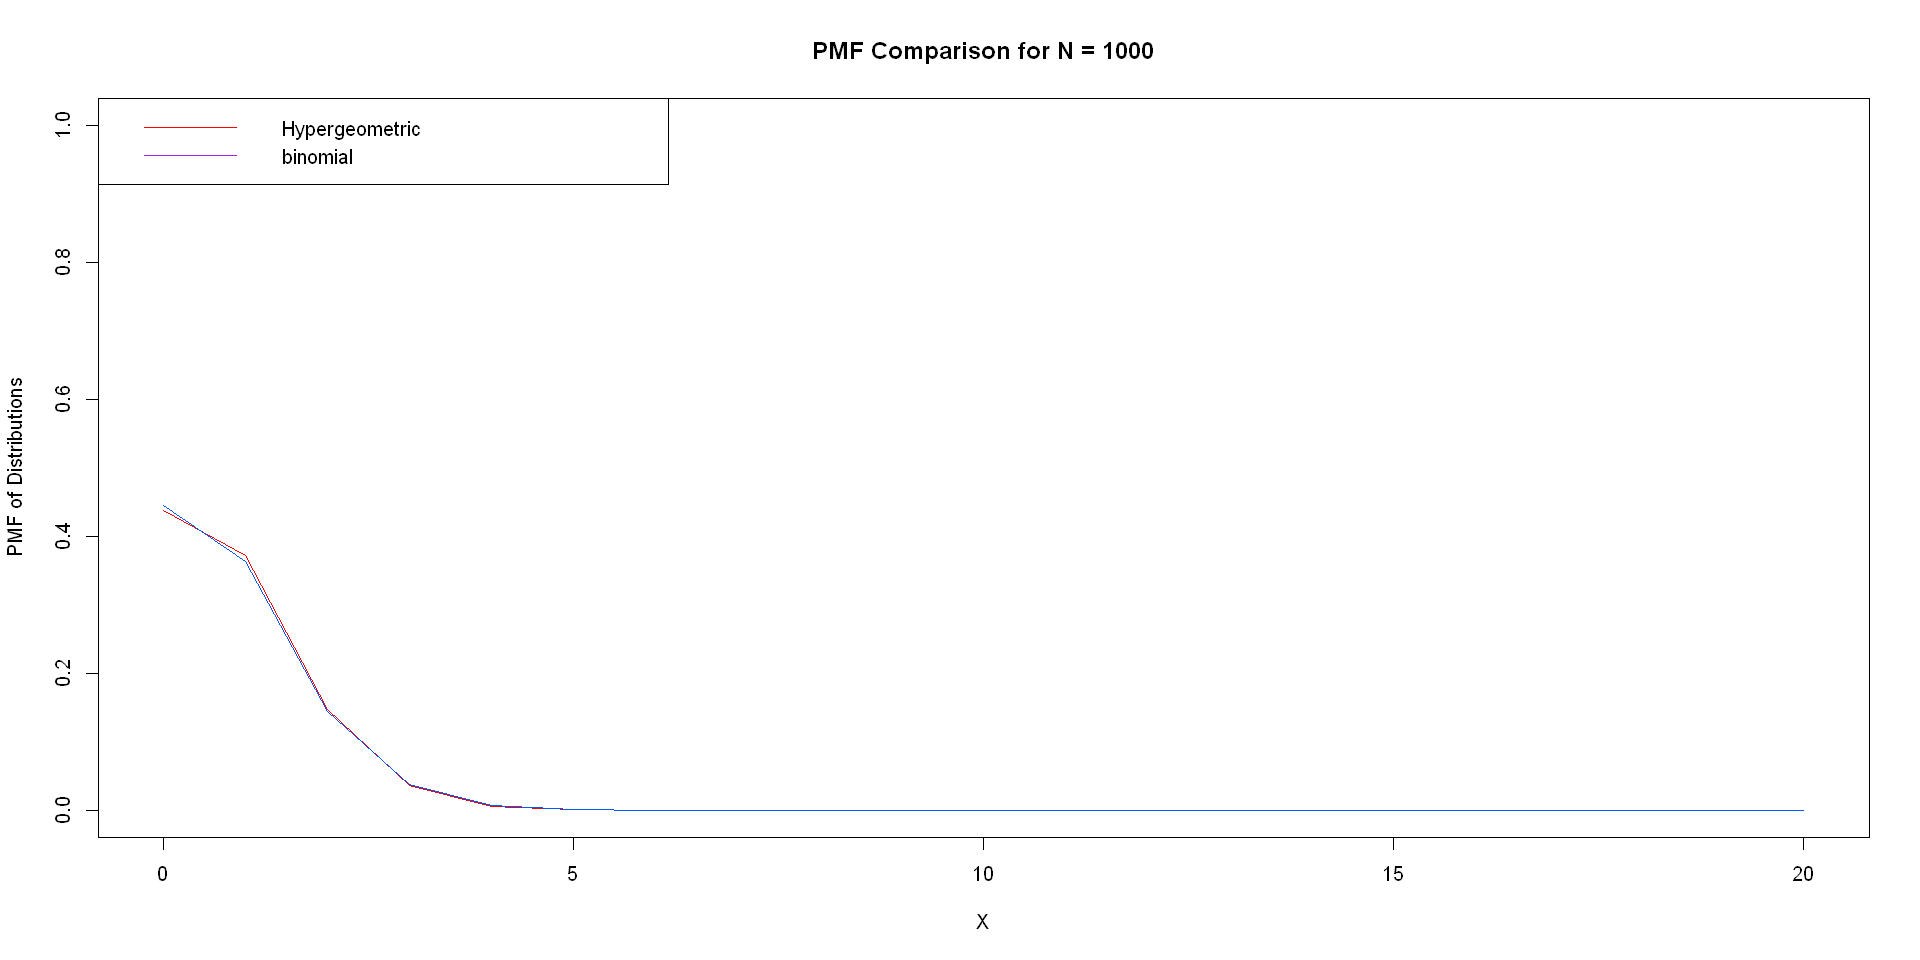

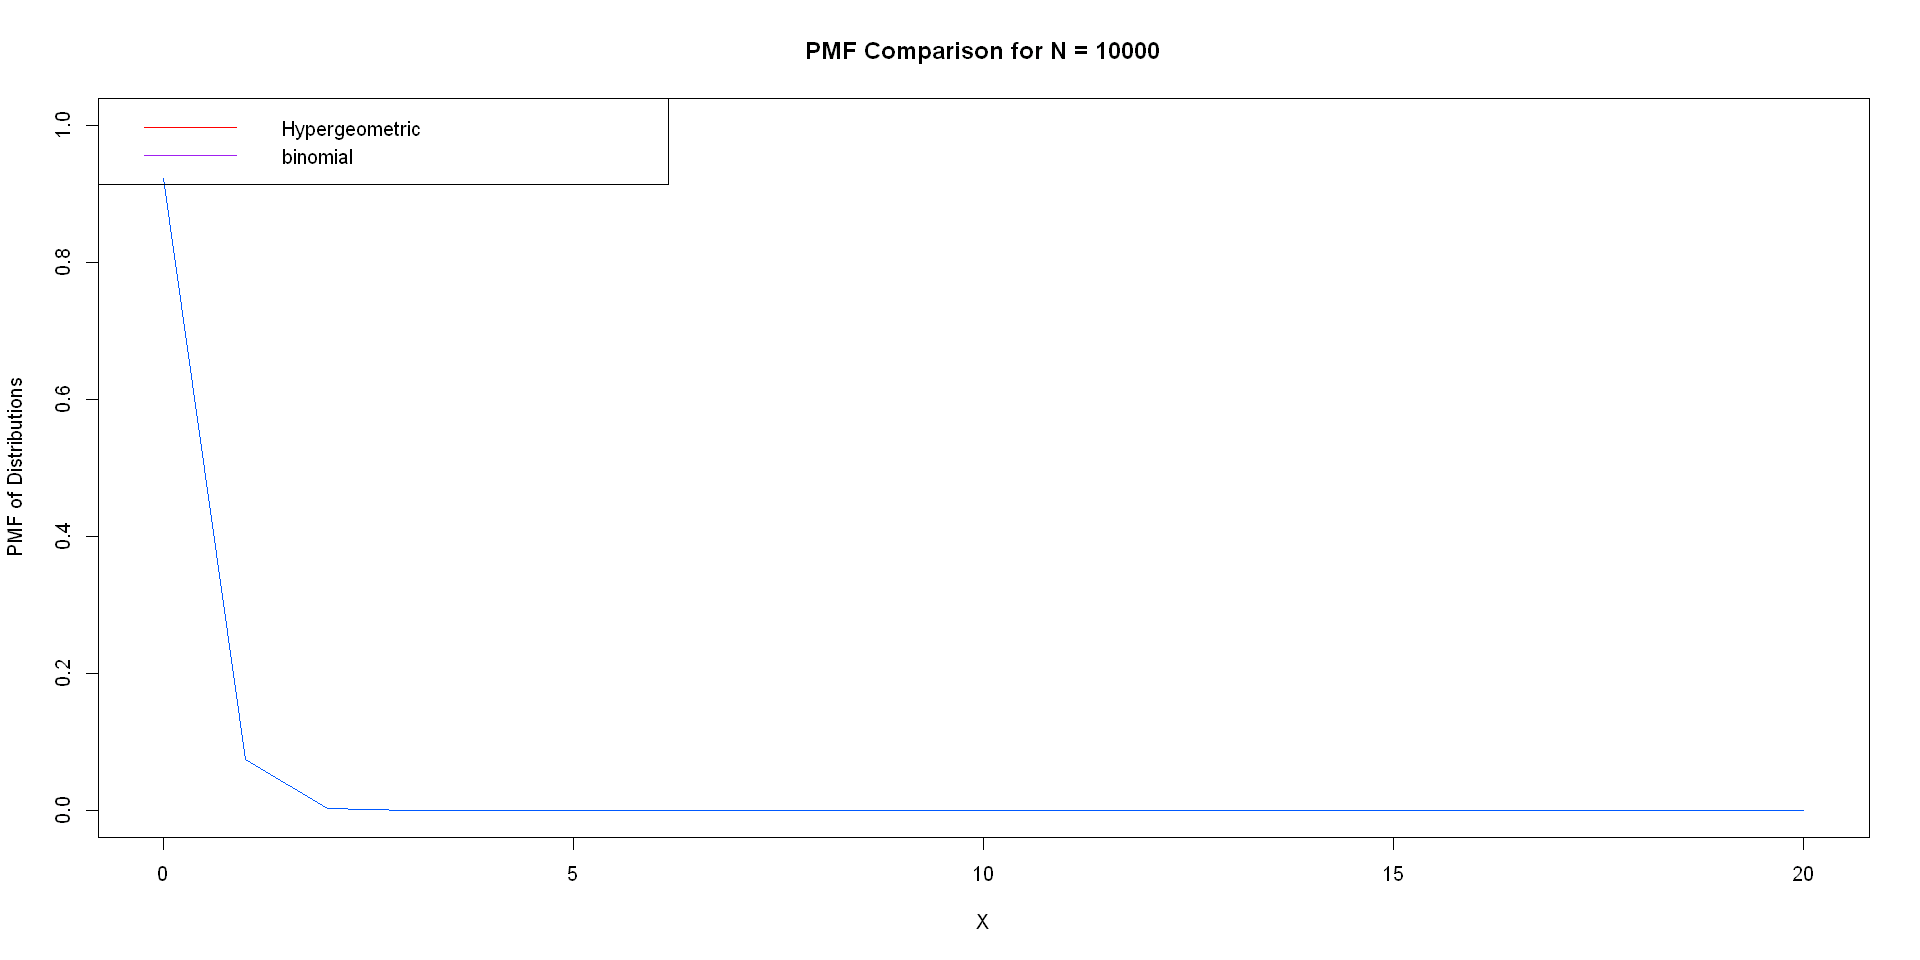

In [26]:
N_values <- c(100, 500, 1000, 10000)
n <- 40
x_limit <- 20
num_of_cheaters <- 20

for(i in 1:4){
    plot(0:num_of_cheaters, calculate_hypergeometric_pmf(N_values[i], num_of_cheaters, n, 0:num_of_cheaters), type = "l", col = "red", 
        xlab = "X", ylab = "PMF of Distributions", 
        main = paste("PMF Comparison for N =", N_values[i]), ylim = c(0, 1), xlim = c(0, x_limit))
    
    p <- num_of_cheaters / N_values[i]
    lines(0:num_of_cheaters, calculate_binomial_pmf(n, p, 0:num_of_cheaters), col = "#0059ff")
    legend("topleft", legend = c("Hypergeometric", "binomial"), col = c("red", "purple"), lty = 1)
}


<span style="color: gold; font-size: 30px;">Part 7: Analyzing Part 6</span>

As we can see, the more we enhance the value of N the more hypergeometric distribution gets close to binomial distribution. This means when N>>n we can estimate the hypergeometric distribution with binomial distribution with n and p of K/N. 

<span style="color: red; font-size: 20px;">NOTE: </span> There has to be a ration between the value of K(in my code it is num of cheaters) and N.Because if we approach N to infinity and keep K constant, the limit of p will be equal to 0 and binomial distribution won't have any meaning. 

When N was equal to 100 the difference between hypergeometric and binomial distributions graphs is highly recognizable. 

For N = 500 the difference decreases a lot and for N = 1000 the difference is almost not recognizable.

And finally for N = 10000 the two graphs completely overlap and you can hardly find an interval which they have differenc in.

<span style="color: #177cff; font-size: 40px;">Question 2: Binomial and Normal Distributions</span>

<span style="color: gold; font-size: 30px;">Part 1: Calculating CDF For Binomial Distribution</span>

I'll calculate the CDF by summing all the pmf values for all x less than or equal to the desired x. 



In [9]:
set.seed(467)

calculate_binomial_cdf <- function(n, p, x){
    less_or_equal_to_x <- 0:x
    pmf_values <- calculate_binomial_pmf(n, p, less_or_equal_to_x)
    cdf_value <- sum(pmf_values)

    return(cdf_value)
}

p <- 0.45
n <- 1000
accurate_cdf <- calculate_binomial_cdf(n, p, 430)
cat("The calculated accurate binomial distribution cdf for 430:", accurate_cdf)

The calculated accurate binomial distribution cdf for 430: 0.1074638

<span style="color: gold; font-size: 30px;">Part 2: Normal Estimation For Binomial Distribution</span>

Now I estimate Bin(n, p) by N(np, np.(1-p)). To do this in the exams we have to convert P(X <= 430) to P( (X - mean(X)) / std(X) <= (430 - np) / sqrt(np.(1 - p)) ) to be able to use the phi function(cdf for standard normal distribution). But here we have access to pnorm() function which takes mean and std as its arguments and makes it easier :).


This will have some error which I will report.



In [10]:
estimated_cdf <- pnorm(430, mean = n * p, sd = sqrt(n * p * (1 - p)))
cat("The estimation for cdf using normal distribution cdf:", estimated_cdf, "\n")

estimation_error <- abs(accurate_cdf - estimated_cdf)
cat("The estimation error:", estimation_error)


The estimation for cdf using normal distribution cdf: 0.1018139 
The estimation error: 0.005649884

<span style="color: gold; font-size: 30px;">Part 3: Estimating With Continuity Correction</span>

We know that if we estimate the binomial distribution which is a discrete distribution using the normal distribution which is a continuous one, then we'll have some error. According to continuity correction we can reduce the error remarkably using changing the intervals. We should only change inequalities like x <= y to x < y + 0.5. Here x <= 430 so we change it to x < 430.5.



In [11]:
estimated_cdf_corrected <- pnorm(430.5, mean = n * p, sd = sqrt(n * p * (1 - p)))
cat("The estimation for cdf using normal distribution cdf:", estimated_cdf, "\n")

estimation_error_corrected <- abs(accurate_cdf - estimated_cdf_corrected)
cat("The estimation error:", estimation_error_corrected, "\n")
cat("As we can see, the corrected error is as", estimation_error / estimation_error_corrected , "times smaller than the first one.")

The estimation for cdf using normal distribution cdf: 0.1018139 
The estimation error: 0.0001161443 
As we can see, the corrected error is as 48.64537 times smaller than the first one.

<span style="color: gold; font-size: 30px;">Part 4: Plotting The Error Graphs</span>

First I calculate the values for cdf by the three ways, then I calculate the error for estimations and plot them.

From now on instead of using the built-in functions of R for plotting I'll use the ggplot library which is much more professional and efficient.


Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


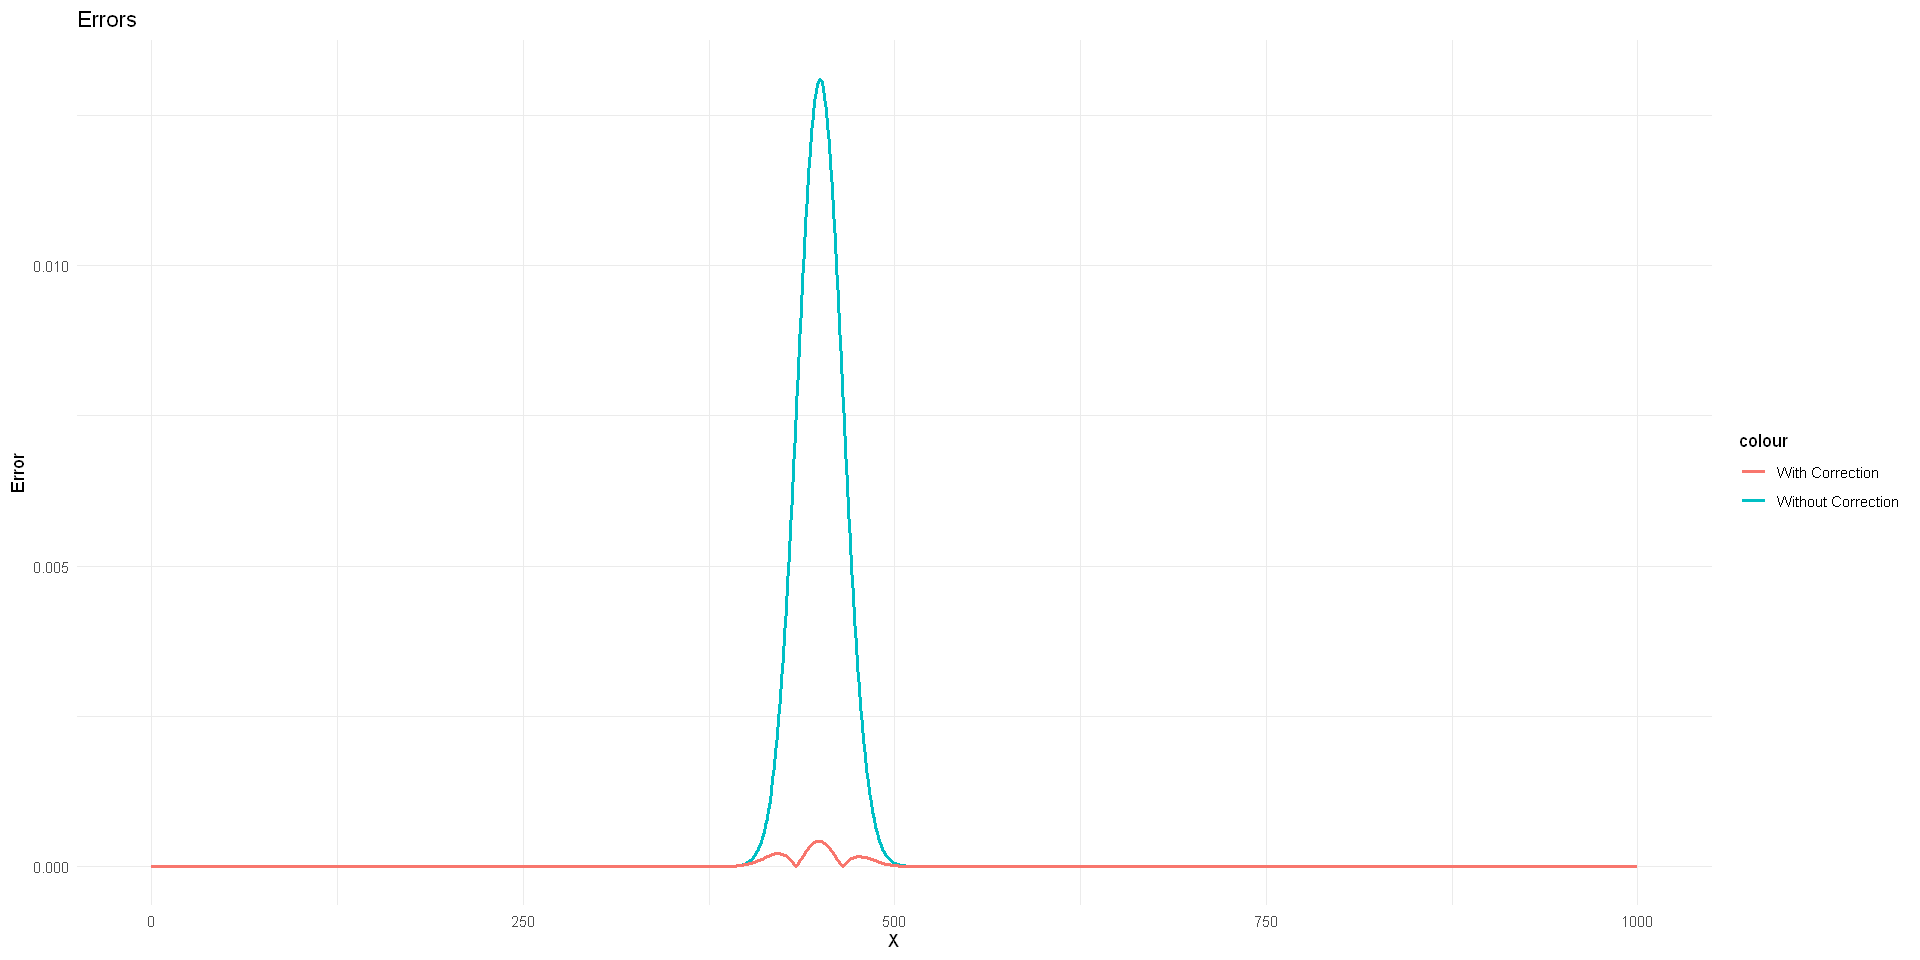

In [12]:
library(ggplot2)

X_values <- 0:1000
accurate_cdf_values <- numeric(length(X_values))
estimated_cdf_values_not_corrected <- numeric(length(X_values))
estimated_cdf_errors_not_corrected <- numeric(length(X_values))
estimated_cdf_values_corrected <- numeric(length(X_values))
estimated_cdf_errors_corrected <- numeric(length(X_values))

for(i in seq_along(X_values)){
    accurate_cdf_values[i] <- calculate_binomial_cdf(n, p, X_values[i])
    estimated_cdf_values_not_corrected[i] <- pnorm(X_values[i], mean = n * p, sd = sqrt(n * p * (1 - p)))
    estimated_cdf_errors_not_corrected[i] <- abs(estimated_cdf_values_not_corrected[i] - accurate_cdf_values[i])
    estimated_cdf_values_corrected[i] <- pnorm(X_values[i] + 0.5, mean = n * p, sd = sqrt(n * p * (1 - p)))
    estimated_cdf_errors_corrected[i] <- abs(estimated_cdf_values_corrected[i] - accurate_cdf_values[i])
}

ggplot() + 
    geom_line(data = data.frame(x = X_values, y = estimated_cdf_errors_not_corrected), aes(x = x, y = y, color = "Without Correction"), size = 1) +
    geom_line(data = data.frame(x = X_values, y = estimated_cdf_errors_corrected), aes(x = x, y = y, color = "With Correction"), size = 1) + 
    labs(title = "Errors", x = "X", y = "Error") +
    theme_minimal()


Analyzing the two graphs proves that estimating with continuity correction has much less error than without. Also we can see that this differece has a peak about np=450 which is the expectation of the distribution. Both normal and binomial distributions have low acceleration on the low or high values of X; so in the middle points of X which is the mean, they have the most difference. This is why we have a peak up there arount 450.

<span style="color: gold; font-size: 30px;">Part 5: Plotting Different Versions Of CDF</span>

I'll plot the accurate, with and without continuity correction versions of cdf in [440, 460] interval for X.


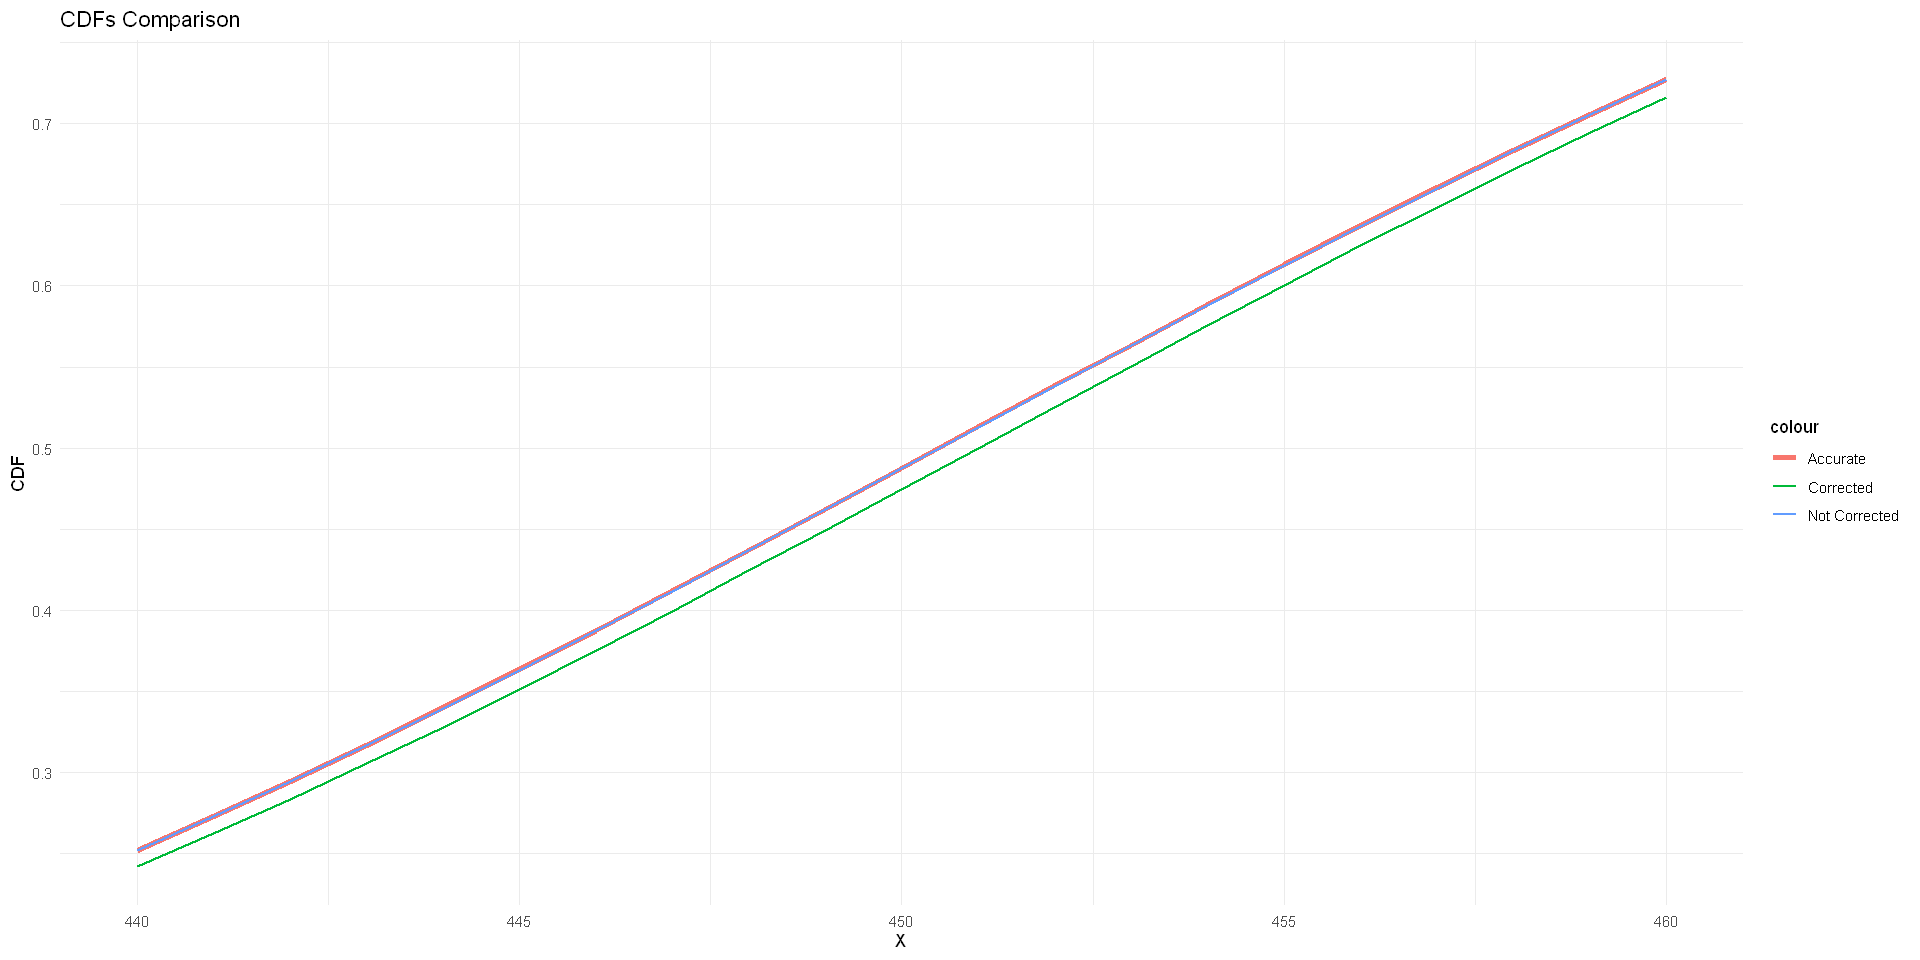

In [13]:
ggplot() + 
    geom_line(data = data.frame(x = 440:460, y = accurate_cdf_values[440:460]), aes(x = x, y = y, color = "Accurate"), size = 1.5) +
    geom_line(data = data.frame(x = 440:460, y = estimated_cdf_values_not_corrected[440:460]), aes(x = x, y = y, color = "Corrected"), size = 0.8) +
    geom_line(data = data.frame(x = 440:460, y = estimated_cdf_values_corrected[440:460]), aes(x = x, y = y, color = "Not Corrected"), size = 0.8) + 
    labs(title = "CDFs Comparison", x = "X", y = "CDF") +
    theme_minimal()

ggsave("p.png", width = 10, height = 8, dpi = 900)

As you can see, the corrected version is approximately identical to the accurate version. They've completely overlapped. But the not corrected version has a considerable error.

<span style="color: gold; font-size: 30px;">Part 6: Time Analysis For Normal and Binomial Distributions</span>

We'll measure and compare the times that each of the binomial and normal distributions take to calculate the CDF. 


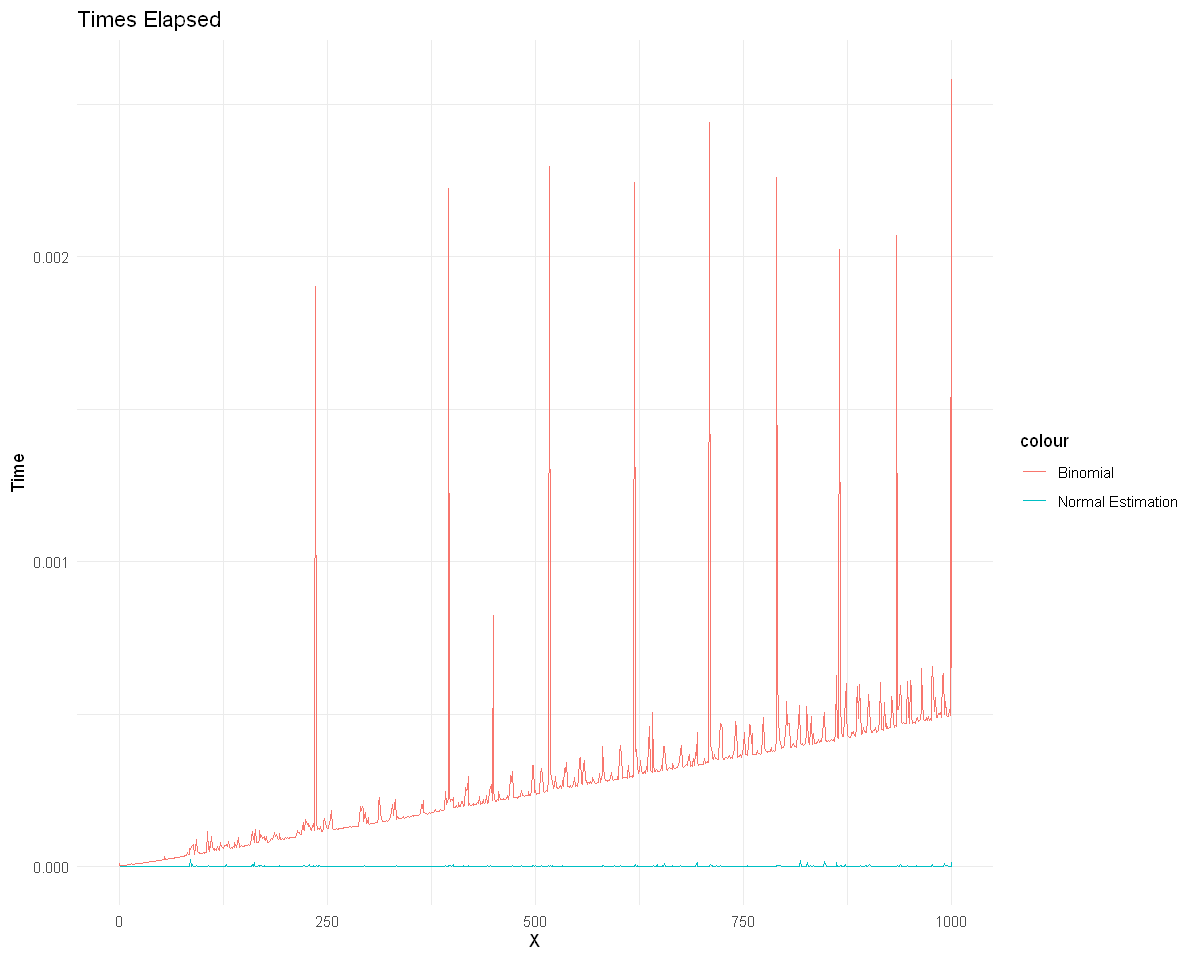

In [14]:
options(repr.plot.width = 10, repr.plot.height = 8) #Just to make the graphs more well-sized.

normal_estimation_times <- numeric(length(X_values))
accurate_value_times <- numeric(length(X_values))

for(i in seq_along(X_values)){
    start_time <- Sys.time()
    estimated_cdf_values_corrected[i] <- pnorm(X_values[i] + 0.5, mean = n * p, sd = sqrt(n * p * (1 - p)))
    end_time <- Sys.time()
    normal_estimation_times[i] <- end_time - start_time

    start_time <- Sys.time()
    accurate_cdf_values[i] <- calculate_binomial_cdf(n, p, X_values[i])
    end_time <- Sys.time()
    accurate_value_times[i] <- end_time - start_time
}

ggplot() + 
    geom_line(data = data.frame(x = X_values, y = normal_estimation_times), aes(x = x, y = y, color = "Normal Estimation"), size = 0.1) +
    geom_line(data = data.frame(x = X_values, y = accurate_value_times), aes(x = x, y = y, color = "Binomial"), size = 0.1) + 
    labs(title = "Times Elapsed", x = "X", y = "Time") +
    theme_minimal()

    # ggsave("p.png", width = 10, height = 8, dpi = 300)

options(repr.plot.width = 16, repr.plot.height = 8) #Just to make the graphs more well-sized.


This shows that normal estimation needs much less time to calculate the cdf and the time which binomial cdf calculater needs enhances when X goes more.

<span style="color: gold; font-size: 30px;">Part 7: Choosing Better Method</span>

Now we calculate the expenses and say which method is appropriate for each value of X.

In [15]:
X_period <- 400:600
binomial_time_wastings <- c()
normal_errors <- c()
time_wasting_penalty <- 100
error_penalty <- 1000000

for(i in X_period){
    normal_errors <-  c(normal_errors, estimated_cdf_errors_corrected[i])
    binomial_time_wastings <- c(binomial_time_wastings, accurate_value_times[i] - normal_estimation_times[i])
}

first_normal_estimation <- function(X_period, binomial_time_wastings, normal_errors, time_wasting_penalty, error_penalty){
    for(i in X_period){
        normal_expense <-  normal_errors[i - X_period[1] + 1] * error_penalty
        binomial_expense <- binomial_time_wastings[i - X_period[1] + 1] * time_wasting_penalty

        if(binomial_expense > normal_expense){
            return(i)
        }
    }
}

first_normal_estimation(X_period, binomial_time_wastings, normal_errors, time_wasting_penalty, error_penalty)

[1] 529

<span style="color: gold; font-size: 30px;">Part 8: Calculating The Final Expenses</span>


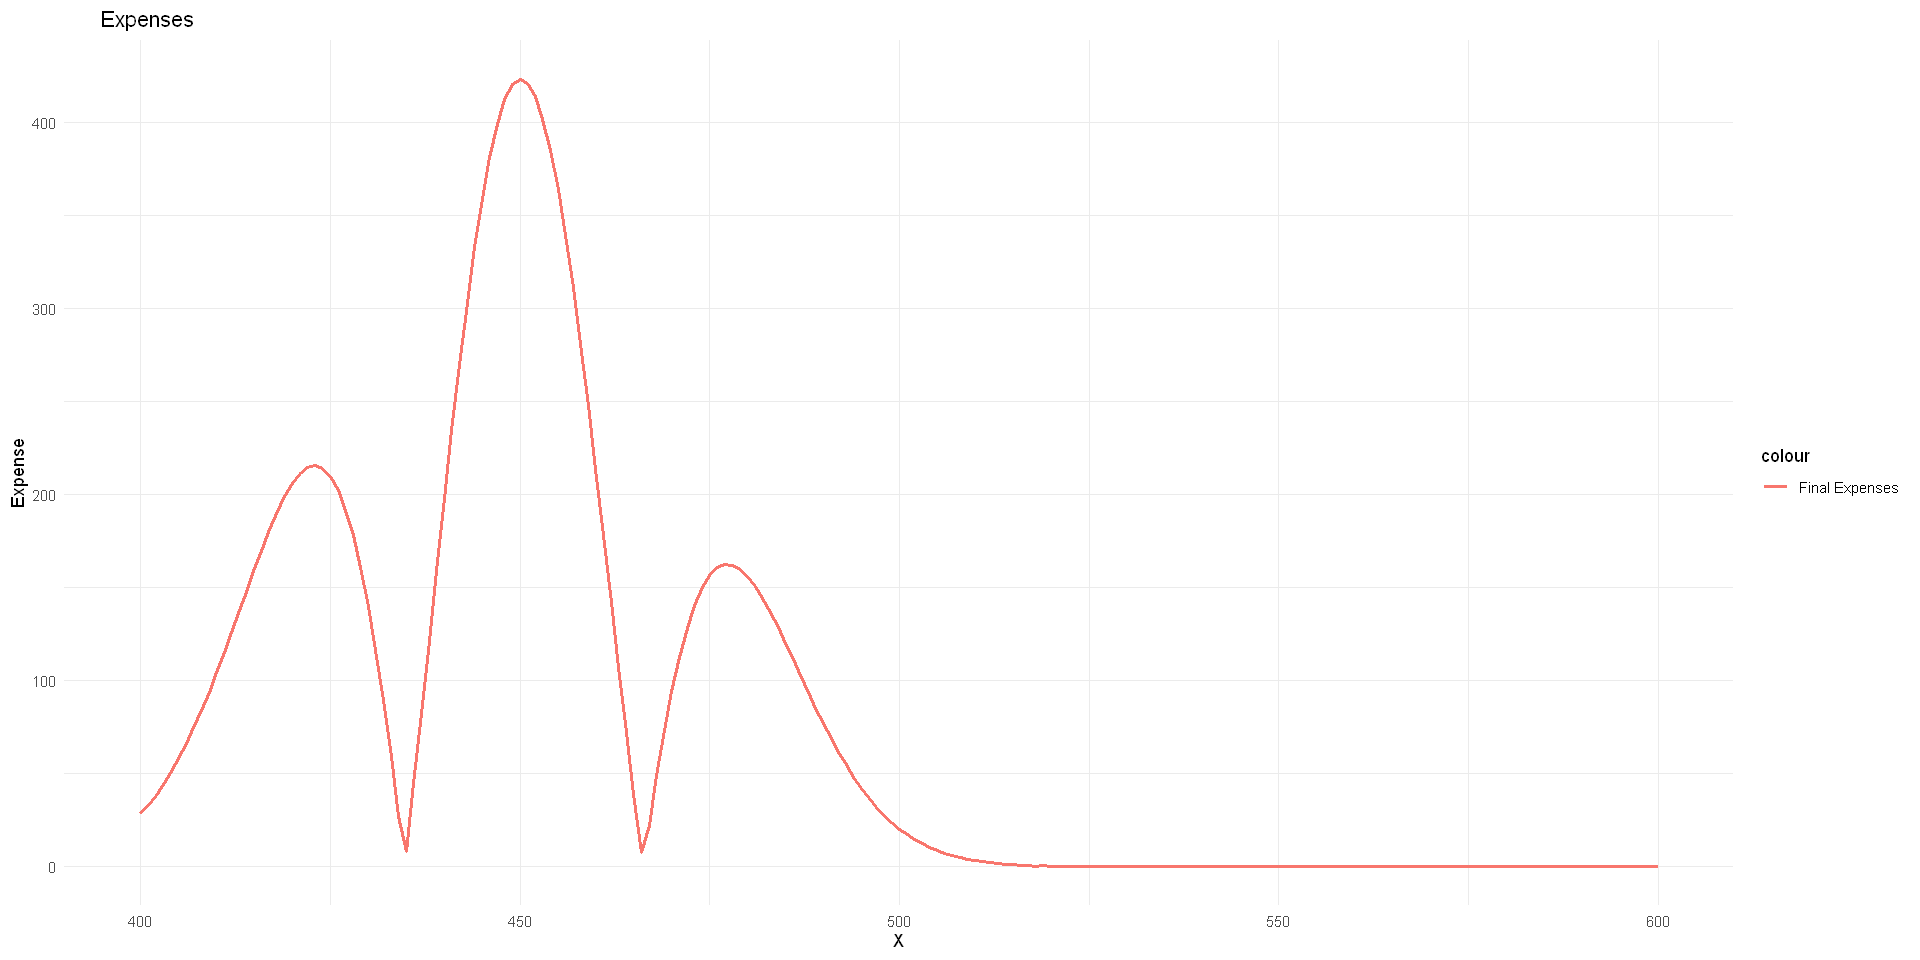

In [16]:
final_expenses <- c()

for(i in X_period){
    normal_expense <-  estimated_cdf_errors_corrected[i] * error_penalty
    binomial_expense <- (accurate_value_times[i] - normal_estimation_times[i]) * time_wasting_penalty
    final_expenses <- c(final_expenses, (normal_expense - binomial_expense))
}

ggplot() + 
    geom_line(data = data.frame(x = X_period, y = final_expenses), aes(x = x, y = y, color = "Final Expenses"), size = 1) +
    labs(title = "      Expenses", x = "X", y = "Expense") +
    theme_minimal()


This graph shows that for X > 529 the expense difference between methods gets much reduced and too close to 0(it's negative.) 

So the answer to the question is yes. For X = 430 calculating the CDF using the binomial method is much more rational. Becuase a large amount of error will be gained if we use the normal estimation.

<span style="color: #177cff; font-size: 40px;">Question 3: Memorylessness Of Exponential Distribution</span>



<span style="color: gold; font-size: 30px;">Part 1: Generating n Samples Exponentially Distributed</span>


In [17]:
set.seed(467)

generate_exponential_distribution_samples <- function(lambda, num_of_samples) {
    samples <- rexp(num_of_samples, rate = lambda)
    return(samples)
}

<span style="color: gold; font-size: 30px;">Part 2: Saving More Than 12 Minutes Time Periods</span>

I'll iterate over the exponential samples and store each value which is between 12 and 8h * 60 = 480 minutes in another list.


In [18]:
extract_more_than_12_times <- function(exponential_samples){
    more_than_12_samples <- c()

    for(i in exponential_samples){
        if(i > 12 && i <= 480){
            more_than_12_samples <- c(more_than_12_samples, i - 12)
        }
    }

    return(more_than_12_samples)
}

<span style="color: gold; font-size: 30px;">Part 3: Showing The Histograms</span>

I'll plot the distribution histogram for each value of m.

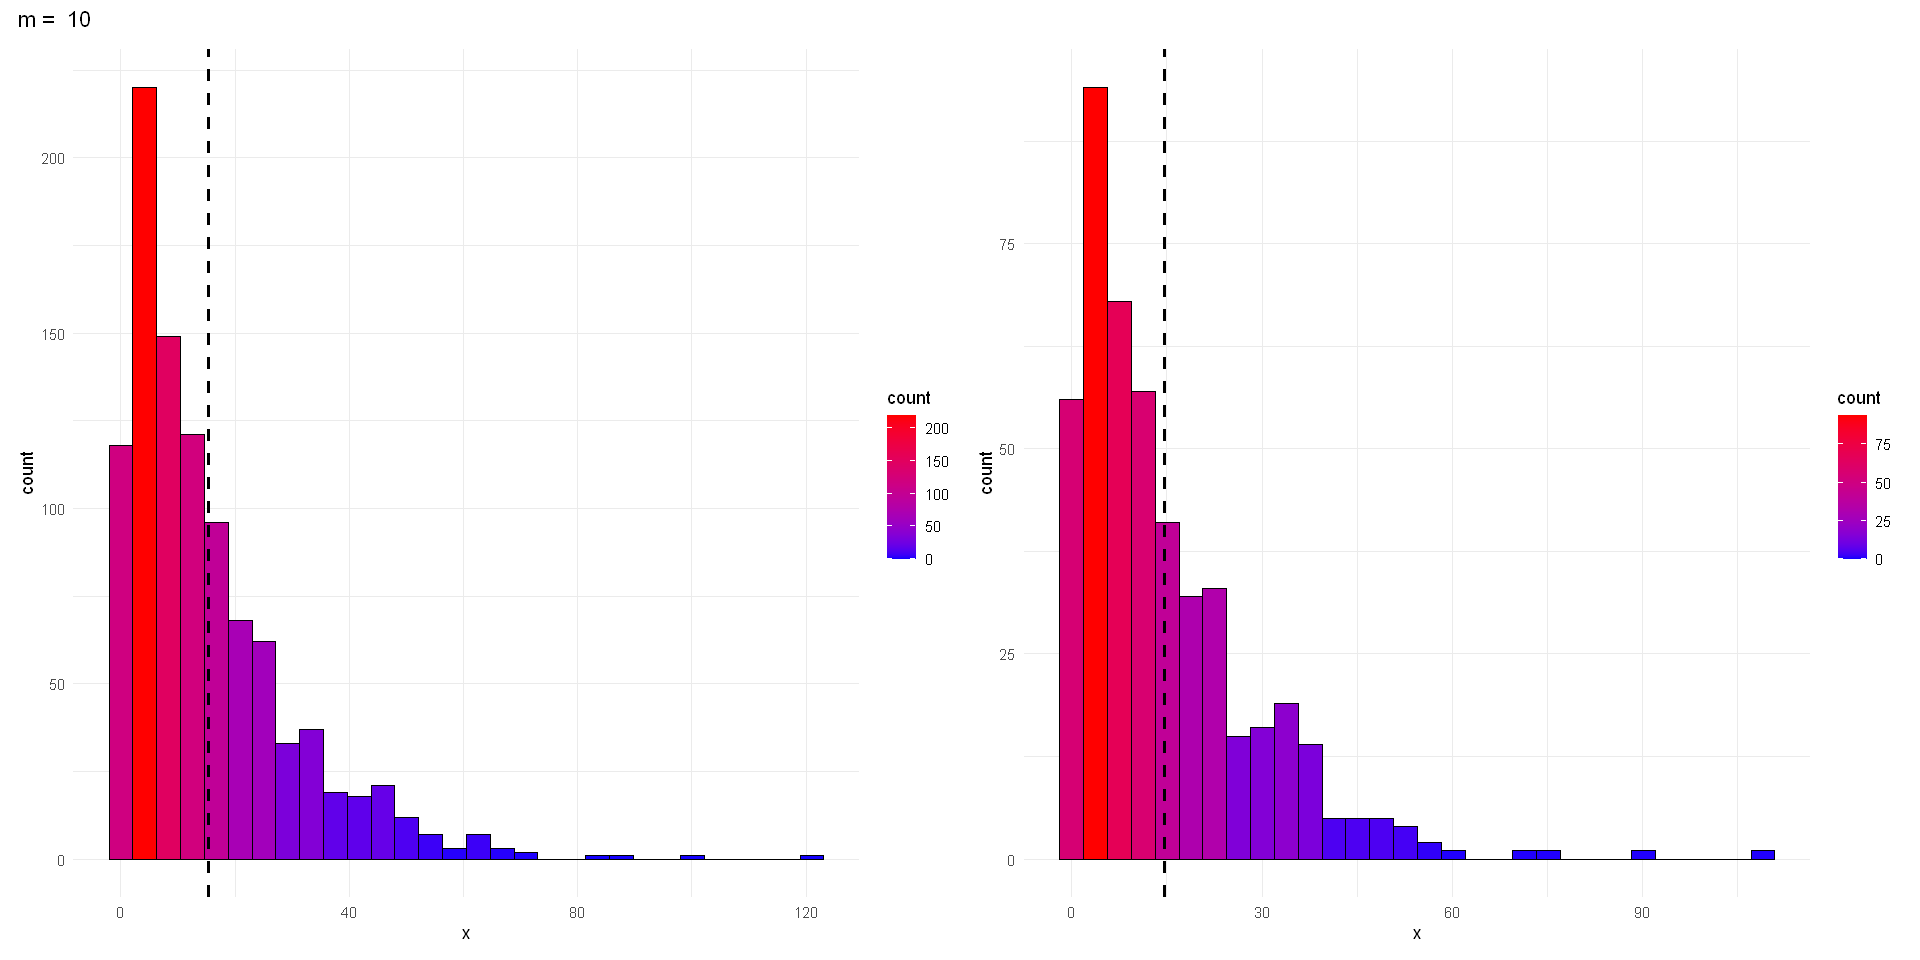

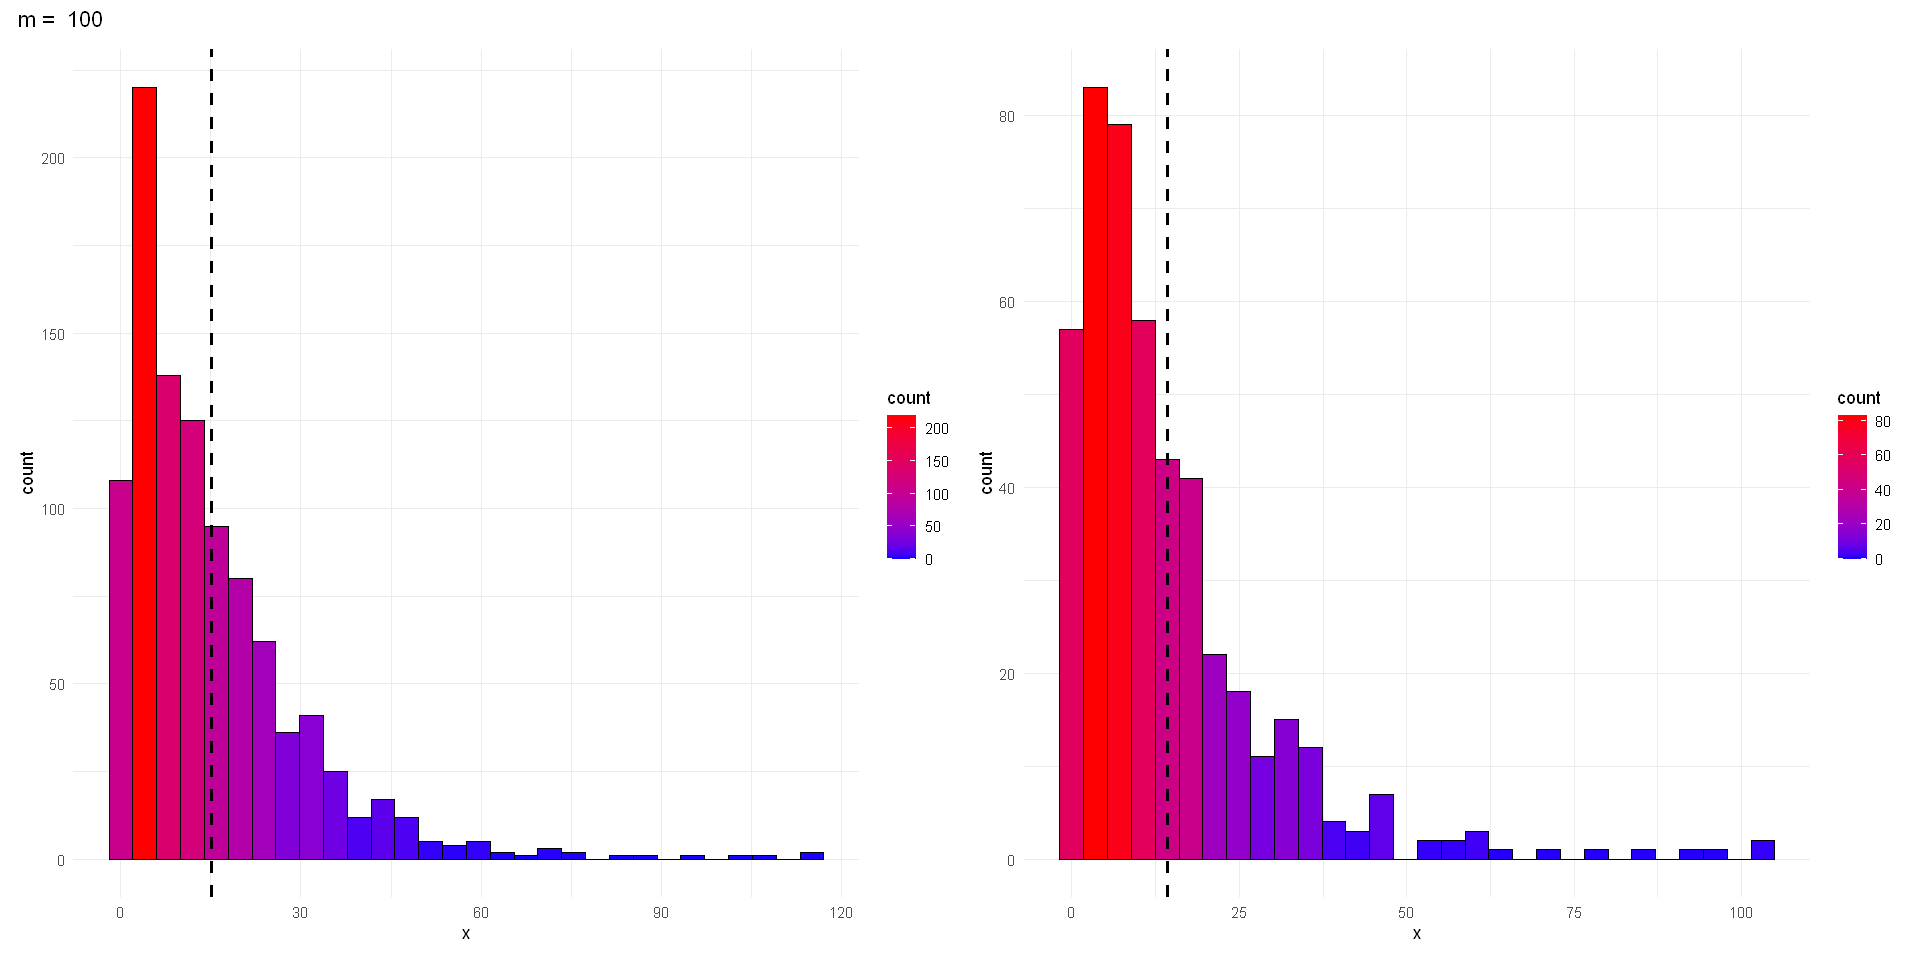

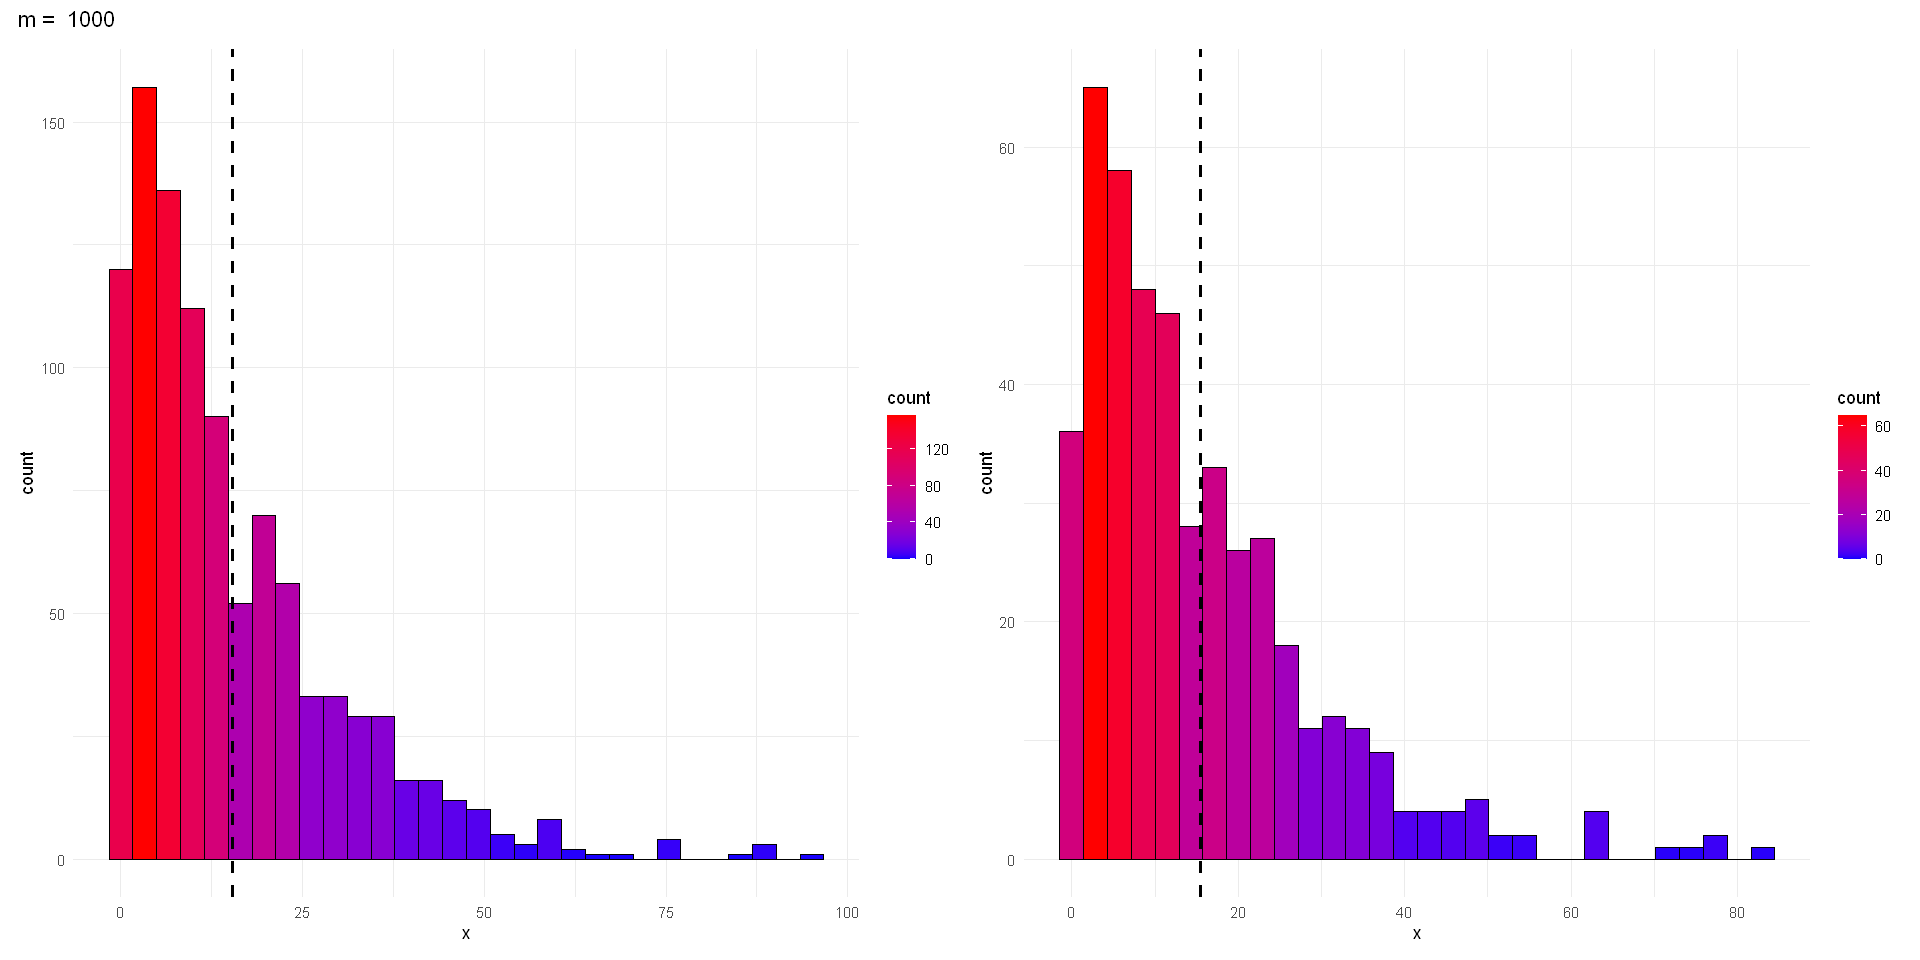

In [25]:
library(patchwork)
m_values = c(10, 100, 1000)
lambda <- 1/15

for(m in m_values){
    exponential_samples <- generate_exponential_distribution_samples(lambda, 100 * m_values[1])

    p1 <- ggplot(data = data.frame(x = exponential_samples), aes(x = x)) + 
        geom_histogram(aes(fill = ..count..), bins = 30, color="#000000") +
        scale_fill_gradient(low = "blue", high = "red") +
        geom_vline(aes(xintercept=mean(exponential_samples)), color="#000000", linetype="dashed", size=1) +
        theme_minimal()


    more_than_12_samples = extract_more_than_12_times(exponential_samples)
    p2 <- ggplot(data = data.frame(x = more_than_12_samples), aes(x = x)) + 
        geom_histogram(aes(fill = ..count..), bins = 30, color="#000000") +
        scale_fill_gradient(low = "blue", high = "red") +
        geom_vline(aes(xintercept=mean(more_than_12_samples)), color="#000000", linetype="dashed", size=1) +
        theme_minimal()
    #This is for making the limit of width for image print a bit more to be able to locate two plots in one shape.
    
    combined_plot <- (p1 | p2) +
    plot_annotation(
        title = paste("m = ", m)
    )

    print(combined_plot)
}



<span style="color: gold; font-size: 30px;">Part 4: Analyzing The Histograms</span>

As we can see in the histograms, the distribution histogram for times more than 12 minutes is approximately the same as the previous distribution. 

Also it's obvious that when we increase m the diagrams get more identical to the standard exponential distribution diagram.

Also we can see that the mean in both graphs is almost the same in all shapes.

<span style="color: gold; font-size: 30px;">Part 5: Intuition Of Memorylessness</span>

According to the memorylessness for exponential distribution P(X > t + s | X > t) = P(X > s). So one time we simulate and another time we calculate the probability using the theoretical formula. 

The calculated values are approximately equal.

In [20]:
more_than_15_count <- 0
exponential_samples <- generate_exponential_distribution_samples(lambda, 100 * m_values[1])
more_than_12_samples = extract_more_than_12_times(exponential_samples)

for(i in more_than_12_samples){
    if(i > 3){
        more_than_15_count <- more_than_15_count + 1
    }
}

simulated_probability <- more_than_15_count / length(more_than_12_samples)

theoretical_probabilty <- 1 - pexp(3, lambda)

simulated_probability
theoretical_probabilty

[1] 0.8372591

[1] 0.8187308

<span style="color: #177cff; font-size: 40px;">Question 4: Functions Of Random Variables</span>





<span style="color: gold; font-size: 30px;">Part 1, 2 and 3: Comparing The Simulated And Theoretical Distribution For Y</span>

As we can see, the diagrams are approximately the same. So we get the intuition about this conversion.


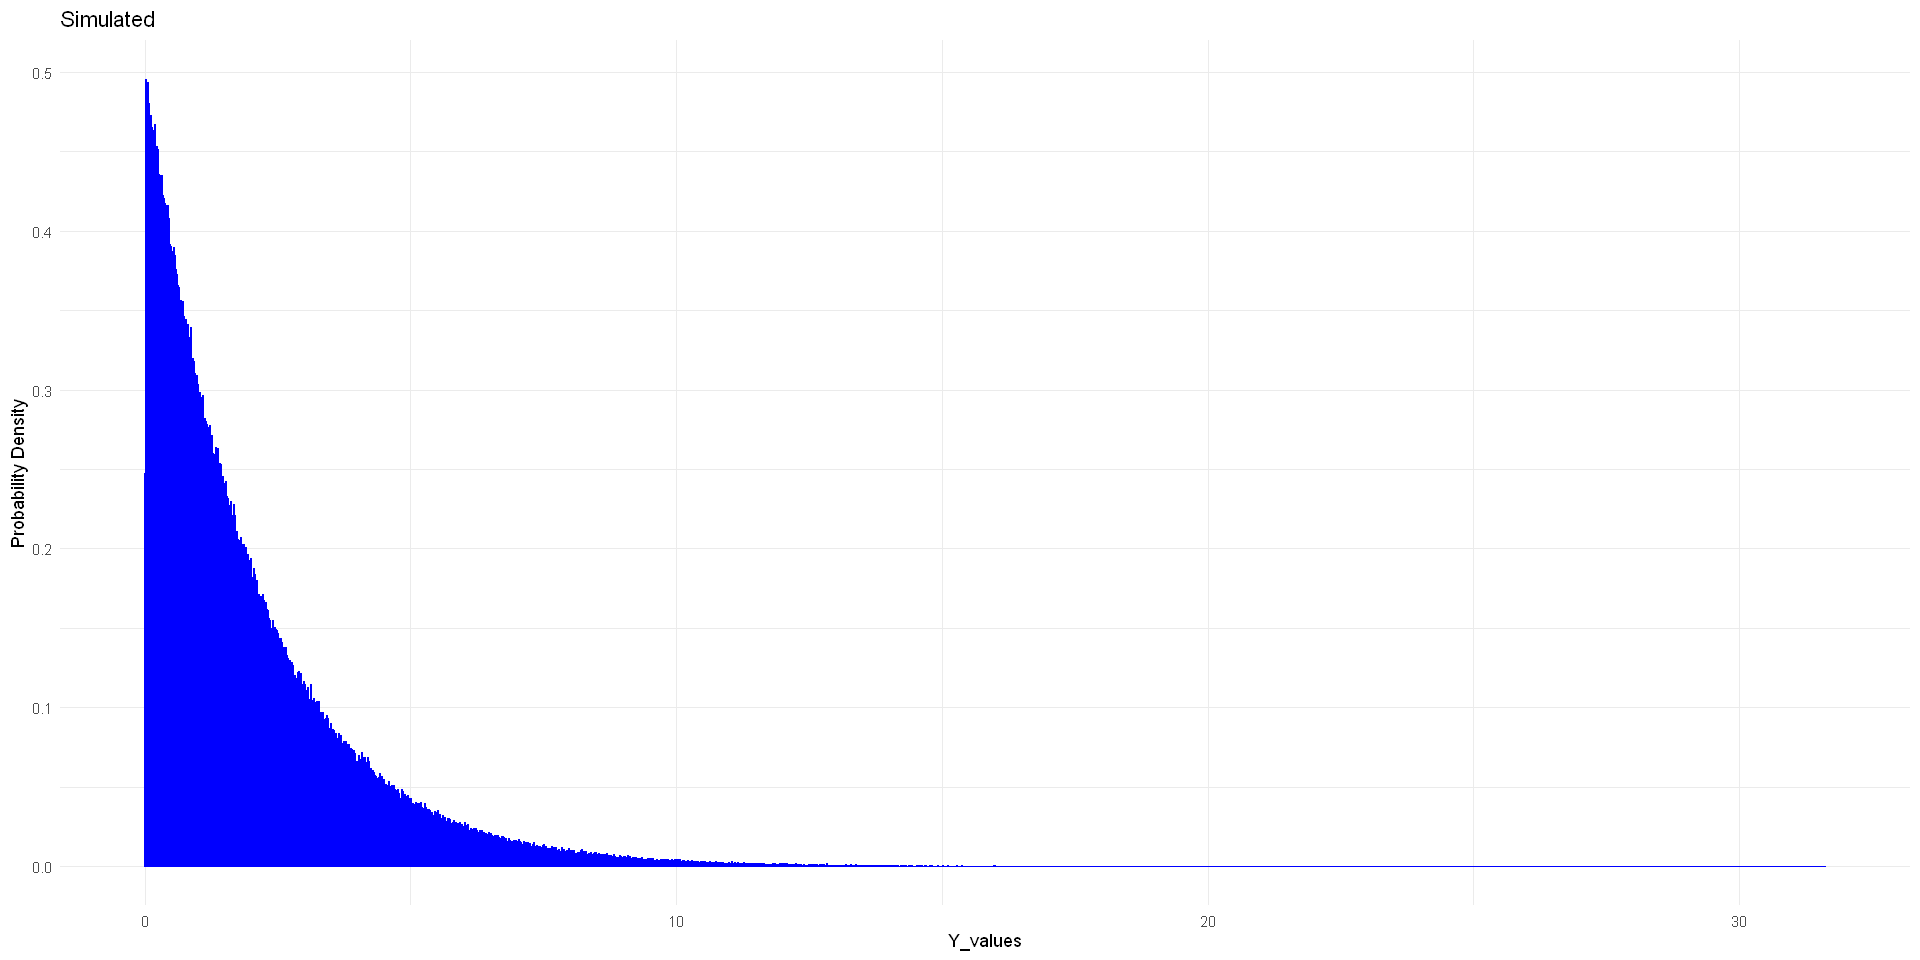

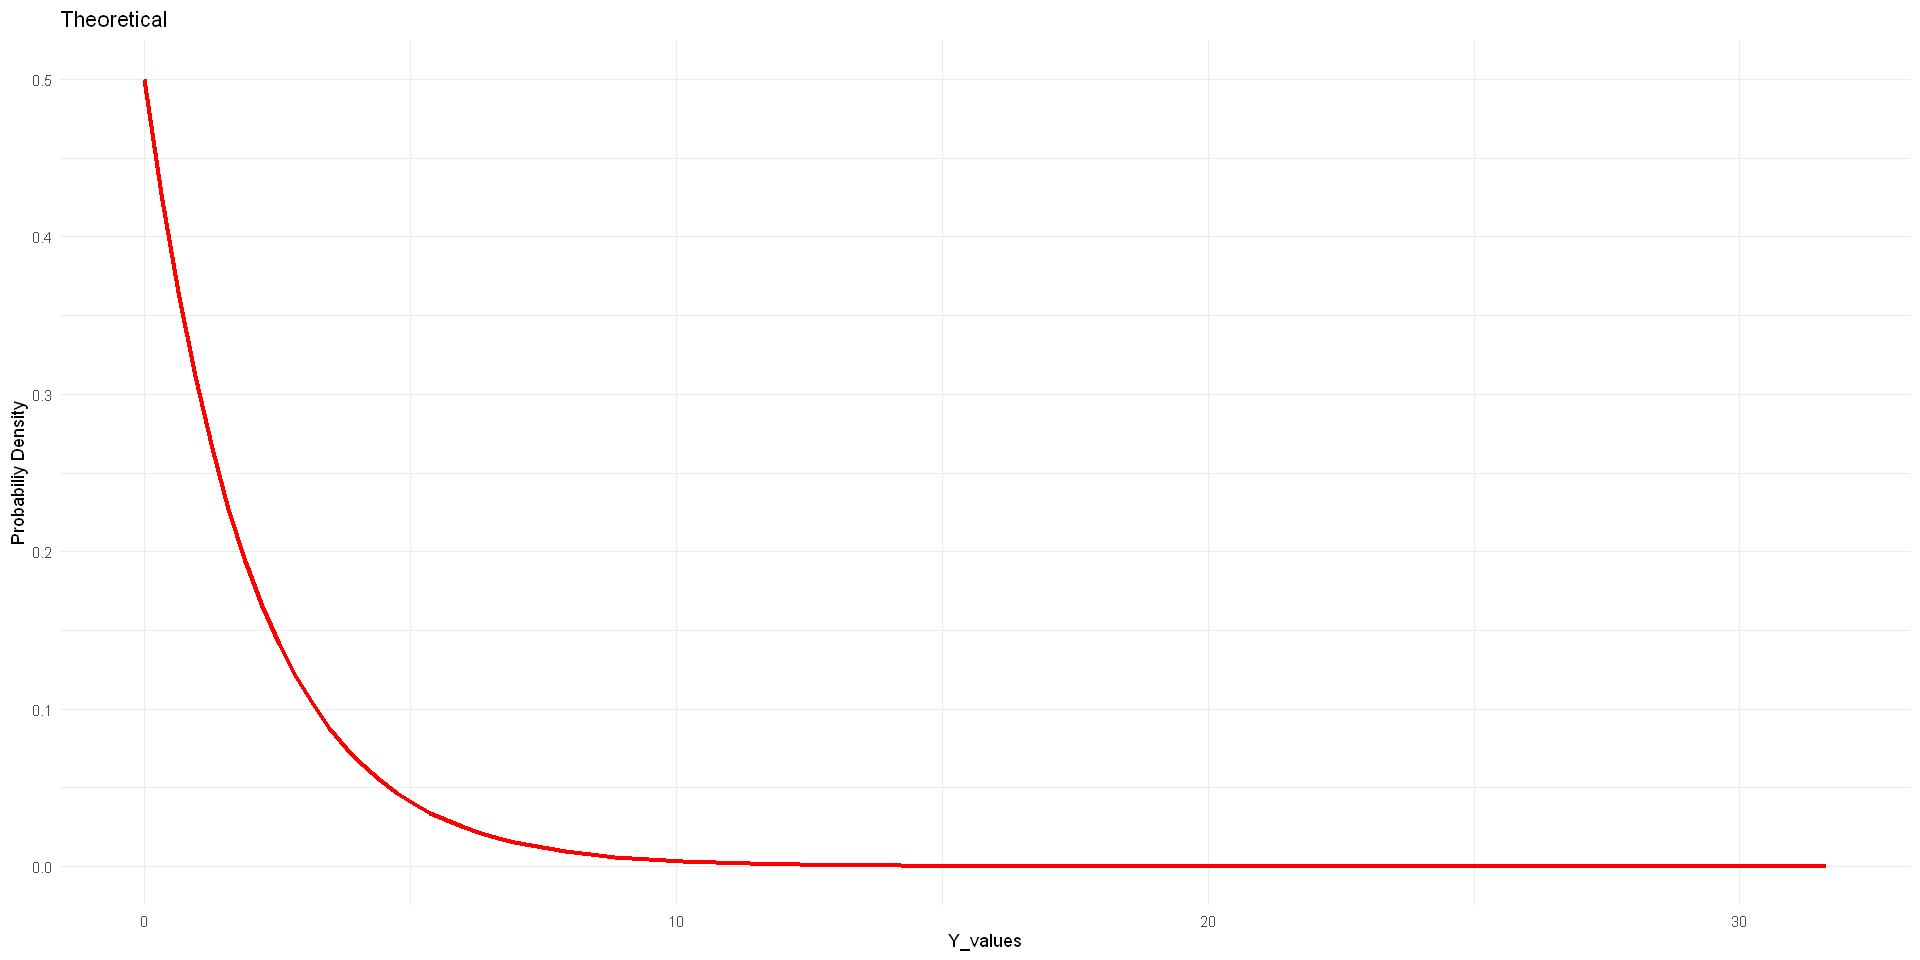

In [ ]:
set.seed(467)

X_values <- runif(1000000, 0, 1)
Y_values <- -2 * log(X_values, base = exp(1))

ggplot(data.frame(Y = Y_values), aes(x = Y)) +
  geom_histogram(color = "blue", aes(y = ..density..), bins = 3000) +
  labs(title = "Simulated", x = "Y_values", y = "Probability Density") +
  theme_minimal()
#It's a histogram actually, but it shows the point!

ggplot(data.frame(x = seq(0, max(Y_values), length.out = 500)), aes(x = x)) +
  stat_function(fun = function(y) (1/2) * exp(-y / 2), color = "red", size = 1.2) +
  labs(title = "Theoretical", x = "Y_values", y = "Probabiliy Density") +
  theme_minimal()

<span style="color: gold; font-size: 30px;">Part 4, 5 and 6: Comparing The Z1 And Z2 To Normal Distribution</span>

As we can see again, the probability distributions for Z1 and Z2 are almost the same as standard normal distribution. This intuitively shows that the converstion works properly.

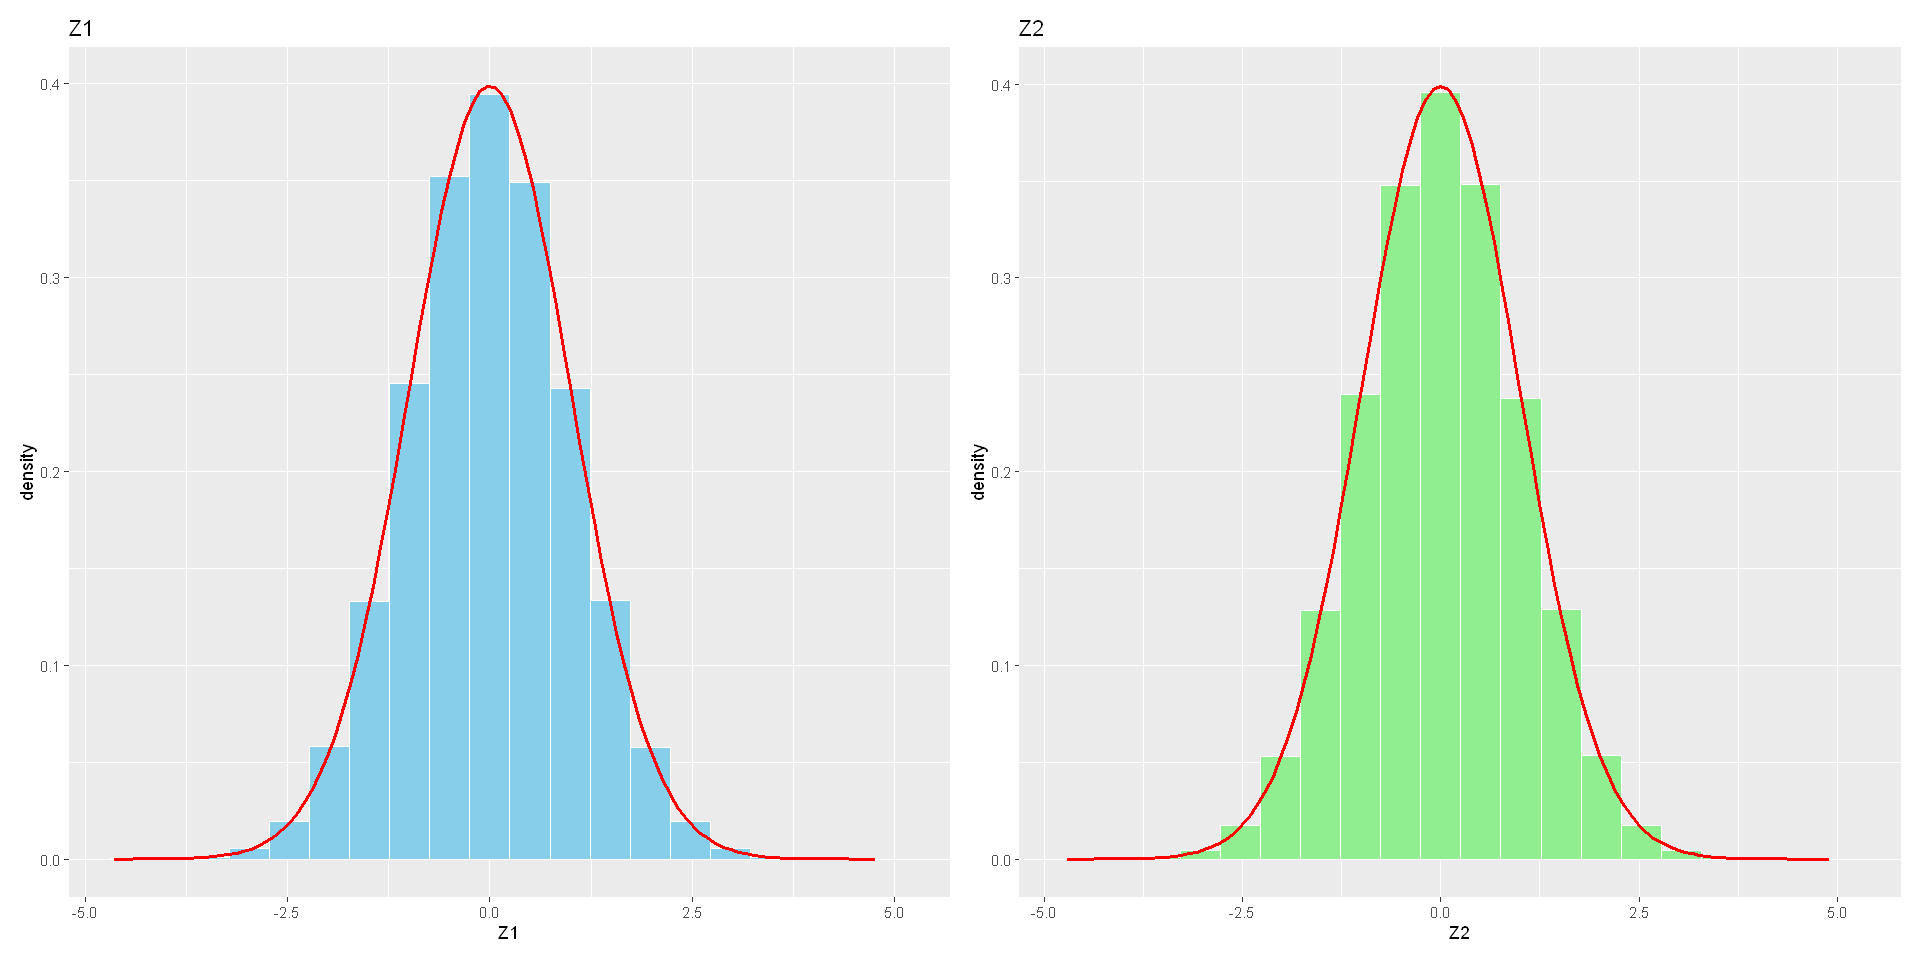

In [22]:
U1_values <- runif(1000000, 0, 1)
U2_values <- runif(1000000, 0, 1)

R = sqrt(-2 * log(U1_values))
theta = 2 * pi * U2_values
Z1 = R * cos(theta)
Z2 = R * sin(theta)

data <- data.frame(Z1, Z2)

p1 <- ggplot(data, aes(x = Z1)) + 
  geom_histogram(aes(y = ..density..), bins = 20, fill = "skyblue", color = "white") + 
  stat_function(fun = dnorm, color = "red", size = 1) + 
  labs(title = "Z1")

p2 <- ggplot(data, aes(x = Z2)) + 
  geom_histogram(aes(y = ..density..), bins = 20, fill = "lightgreen", color = "white") + 
  stat_function(fun = dnorm, color = "red", size = 1) + 
  labs(title = "Z2")

combined_plot <- (p1 | p2)
print(combined_plot)
